In [41]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import brentq
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from datetime import datetime
from pandas.tseries.offsets import BDay
import pandas_datareader.data as pdr

In [42]:
transaction_data = pd.read_excel("./Transaction Data.xlsx")
# print(transaction_data.tail())

In [43]:
all_tickers = list(transaction_data['Ticker'].unique())

#Remove delisted stock
blackList = []

filt_tickers = [tick for tick in all_tickers if tick not in blackList]
print("You traded {} different assets".format(len(all_tickers)))

You traded 12 different assets


In [44]:
filt_tickers

['FANG',
 'ASTS',
 'BTI',
 'NVDA',
 'PLTR',
 'LYG',
 'BTC-USD',
 'SOL-USD',
 'KO',
 'SUI20947-USD',
 'GOOGL',
 'SPCX']

In [45]:
final_filtered = transaction_data[~transaction_data.Ticker.isin(blackList)]

# PRICE HISTORY

In [46]:
start_date = '2021-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

raw = yf.download(
    filt_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

price_data = (
    raw.swaplevel(0, 1, axis=1)   # (Ticker, Field)
       .sort_index(axis=1)
       .stack(level=0)            # Ticker → rows
       .rename_axis(["Date", "Ticker"])
       .reset_index()
       .set_index(["Ticker", "Date"])
       .sort_index()
)

In [47]:
tx = transaction_data.copy()
tx["Date"] = pd.to_datetime(tx["Date"])
tx["Type"] = tx["Type"].str.upper()

# Signed shares & cash flow
tx["Signed_shares"] = tx["Shares"].where(
    tx["Type"] == "BUY", -tx["Shares"])

tx["cash_flow"] = tx["Total Cost/Credit ($)"].where(
    tx["Type"] == "SELL", -tx["Total Cost/Credit ($)"])

tx.tail(10)

,Date,Ticker,Asset,Type,Shares,Cost/Share ($),Commn,Total Cost/Credit ($),Signed_shares,cash_flow
74,2026-06-17,GOOGL,Equity,SELL,0.726624,369.28,0.69,267.637578,-0.726624,267.637578
75,2026-07-08,GOOGL,Equity,BUY,0.508391,365.29,0.47,186.179999,0.508391,-186.179999
76,2026-07-08,BTI,Equity,BUY,5.041766,61.55,0.00,310.320677,5.041766,-310.320677
77,2026-07-08,LYG,Equity,BUY,20.066945,5.99,0.31,120.511000,20.066945,-120.511000
78,2026-07-08,NVDA,Equity,BUY,1.899893,195.49,0.93,372.339999,1.899893,-372.339999
79,2026-07-08,PLTR,Equity,BUY,1.434719,129.44,0.47,186.179999,1.434719,-186.179999
80,2026-07-08,ASTS,Equity,BUY,5.015935,74.05,0.93,372.359999,5.015935,-372.359999
81,2026-07-14,NVDA,Equity,SELL,1.254458,208.27,0.67,260.595914,-1.254458,260.595914
82,2026-07-14,FANG,Equity,SELL,1.085530,193.56,0.54,209.575107,-1.085530,209.575107
83,2026-07-14,KO,Equity,SELL,6.813016,84.26,1.45,572.614733,-6.813016,572.614733


In [48]:
close_prices = price_data["Close"]
close_prices.index = close_prices.index.set_levels(
    pd.to_datetime(close_prices.index.levels[1]),
    level=1)

close_prices

Ticker        Date      
ASTS          2021-01-04    12.950000
              2021-01-05    13.090000
              2021-01-06    12.940000
              2021-01-07    12.780000
              2021-01-08    12.690000
                              ...    
SUI20947-USD  2026-09-27     1.268229
              2026-09-28     1.166706
              2026-09-29     1.150854
              2026-09-30     1.162911
              2026-10-01     1.175595
Name: Close, Length: 17069, dtype: float64

# MONTHLY BUYING


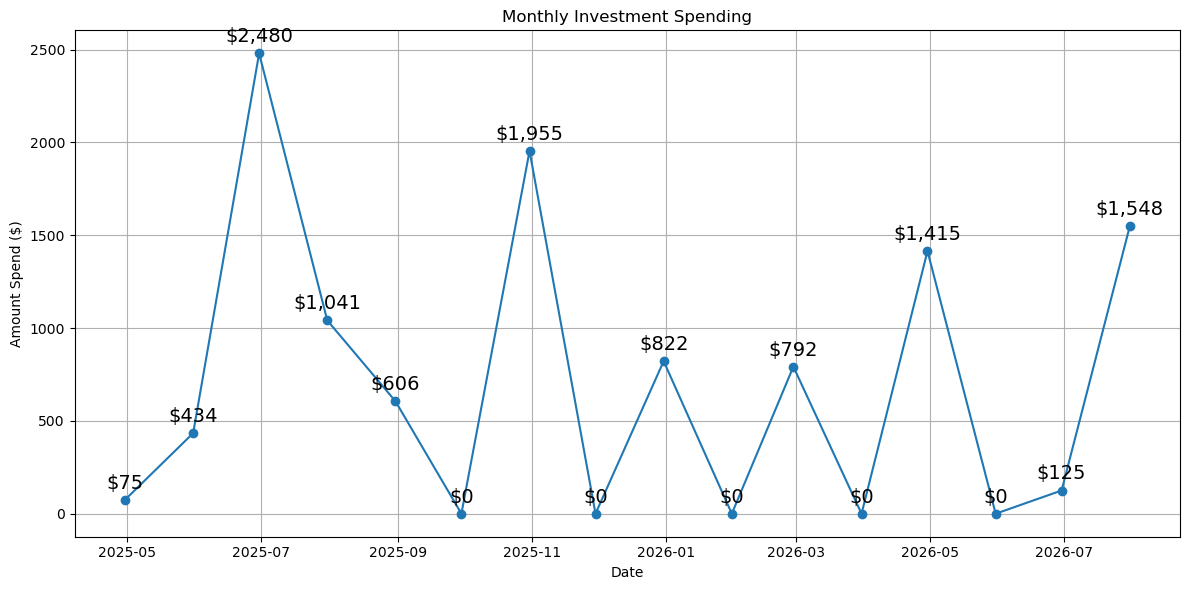

In [49]:
# Keep only Buy transactions 
buy_tx = tx[tx["Type"] == "BUY"].copy()

# Convert to monthy spending
monthly_spending = (buy_tx.set_index("Date").resample("M")["Total Cost/Credit ($)"].sum())

# Plot monthly spending
plt.figure(figsize=(12,6))
plt.plot(
    monthly_spending.index, 
    monthly_spending.values,
    marker = "o"
)
plt.title("Monthly Investment Spending")
plt.xlabel("Date")
plt.ylabel("Amount Spend ($)")
plt.grid(True)

# Add value labels
for x, y in zip(monthly_spending.index, monthly_spending.values):
    plt.annotate(
        f"${y:,.0f}",      # format number
        (x, y),            # point location
        textcoords="offset points",
        xytext=(0, 8),     # vertical offset
        ha="center",
        fontsize= 14
    )


plt.tight_layout()
plt.show()

# NET MONTHLY CF

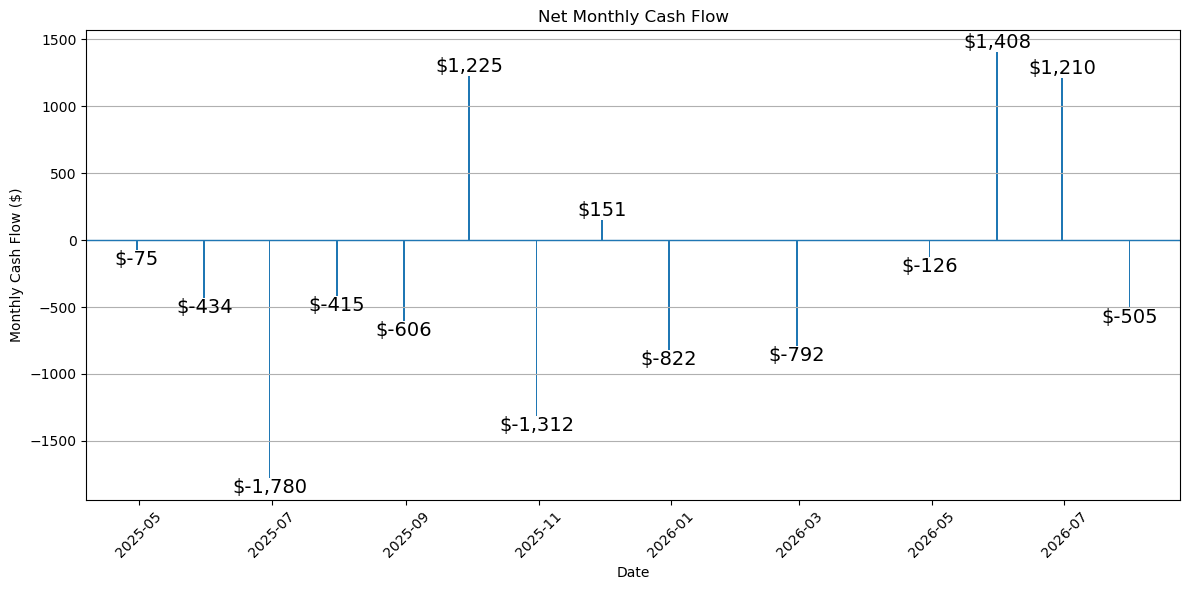

In [50]:
# Convert to Monthy Cash Flow
monthly_net_cf = (tx.set_index("Date").resample("M")["cash_flow"].sum())

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    monthly_net_cf.index,
    monthly_net_cf.values
)

plt.axhline(0, linewidth=1) # Zero line
plt.title("Net Monthly Cash Flow")
plt.xlabel("Date")
plt.ylabel("Monthly Cash Flow ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

# Value Label
for x, y in zip(monthly_net_cf.index, monthly_net_cf.values):
    if y != 0:
        plt.text(
            x,
            y,
            f"${y:,.0f}",
            ha = "center",
            va = "bottom" if y > 0 else "top",
            fontsize = 14
        )
        
plt.tight_layout()
plt.show()

# PORTFOLIO VALUE

In [51]:
### Already have transaction data tx above:
### Build daily holdings per stock

# First transaction date
start_portfolio_date = tx["Date"].min()
prices = close_prices.unstack("Ticker")
prices = prices.loc[prices.index >= start_portfolio_date]

# Forward-fill missing prices (market-closed days)
prices = prices.ffill().fillna(0)

# Aggregate trades by day and ticker:
daily_trades = (
    tx.groupby(["Date", "Ticker"])["Signed_shares"]
    .sum()
    .unstack("Ticker")
    .fillna(0)
)

# Reindex to daily frequency ad forward-fill holdings
daily_trades = daily_trades.reindex(
    prices.index,
    fill_value=0
)

daily_holdings = daily_trades.cumsum()

### Some issue to remember:
# NaNs are expected due to sparse trades and incomplete price histories.
# - No trade on a date ⇒ 0 shares traded (fill NaNs with 0 before cumsum)
# - Missing prices (IPOs, holidays) ⇒ forward-fill after first valid price
# - Assets only contribute to portfolio value once a position exists
# Explicit handling prevents artificial portfolio value drops.

In [52]:
### Porfolio Value
position_values = (
    prices
    .where(daily_holdings != 0, 0)   # only value when held
    .fillna(0)                       # no price → no valuation
    * daily_holdings
)

portfolio_value = position_values.sum(axis=1)

### Invested Capital
# Daily net cash flow
daily_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(portfolio_value.index, fill_value=0)
)

# Cumulative invested capital
invested_capital = (-daily_cash_flow).cumsum()

In [53]:
### Cost Basis Tracking
tx_sorted = tx.sort_values(["Ticker", "Date"]).copy()

records = []
realised_records = []

for ticker, df in tx_sorted.groupby("Ticker"):
    df = df.sort_values("Date")
    
    shares = 0.0
    cost = 0.0
    
    for _, row in df.iterrows():
        date = row["Date"]
        trade_type = row["Type"]
        qty = float(row["Shares"])
        total_cost = float(row["Total Cost/Credit ($)"])
        
        if trade_type == "BUY":
            shares += qty
            cost += total_cost
        
        elif trade_type == "SELL":
            if shares > 0:
                avg_cost = cost / shares
                cost_removed = avg_cost * qty
                
                # realised Pnl
                realised = total_cost - cost_removed
                
                realised_records.append({
                    "Date": date,
                    "Ticker": ticker,
                    "Realised_PnL": realised
                })
                
                shares -= qty
                cost -= cost_removed
        
        avg_cost = cost / shares if shares > 0 else 0
        
        records.append({
            "Date": date,
            "Ticker": ticker,
            "Shares": shares,
            "Cost_Basis": cost,
            "Avg_Cost": avg_cost
        })

cost_basis_df = pd.DataFrame(records)

# remove duplicate Date-Ticker rows (take end-of-day state)
cost_basis_df = (
    cost_basis_df
    .sort_values(["Ticker", "Date"])
    .groupby(["Date", "Ticker"], as_index=False)
    .last()
)

# Pivot to daily matrix
cost_basis_pivot = (
    cost_basis_df
    .set_index(["Date", "Ticker"])["Cost_Basis"]
    .unstack("Ticker")
)

# Align with price index
cost_basis_pivot = cost_basis_pivot.reindex(prices.index).ffill().fillna(0)

# Total portfolio cost basis
portfolio_cost_basis = cost_basis_pivot.sum(axis=1)

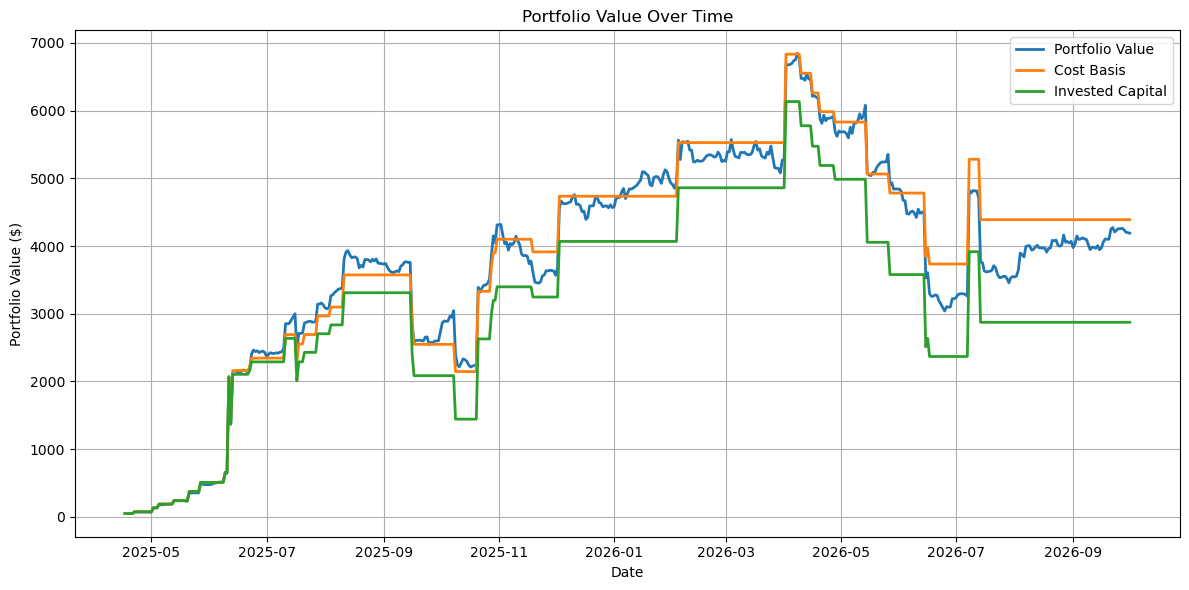

In [54]:


# Plot Portfolio Value + Invested Capital
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_value.index, 
    portfolio_value.values,
    label="Portfolio Value",
    linewidth=2
)

plt.plot(
    portfolio_cost_basis.index,
    portfolio_cost_basis.values,
    label="Cost Basis",
    linewidth=2
)

plt.plot(
    invested_capital.index,
    invested_capital.values,
    label="Invested Capital",
    linewidth=2
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Asset Distribution

In [55]:
# Take the lastest date:
latest_date = position_values.index.max()
latest_positions = position_values.loc[latest_date]

# Remove 0 value:
latest_positions = latest_positions[latest_positions > 0]

([<matplotlib.patches.Wedge at 0x1c3fb93c3d0>,
 [Text(-0.7441862865581371, 0.8100535605123962, 'Crypto'),
  Text(0.744186286558137, -0.8100535605123963, 'Equity')],
 [Text(-0.40591979266807476, 0.44184739664312517, '23.7%'),
  Text(0.4059197926680747, -0.4418473966431252, '76.3%')])

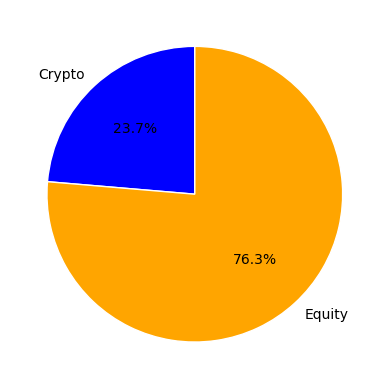

In [56]:
# Mapping asset type
ticker_asset_type = (
    tx[["Ticker", "Asset"]]
    .drop_duplicates()
    .set_index("Ticker")["Asset"]
)

# Aggregate latest portfolio value by asset type
asset_type_values = latest_positions.groupby(
    ticker_asset_type.loc[latest_positions.index]
).sum()

# Define colors by asset type (aligned with index order)
colors = [
    "orange" if asset == "Equity" else "blue"
    for asset in asset_type_values.index
]


# Distribution by Asset Type (Pie Chart - %)
plt.pie(
    asset_type_values,
    labels=asset_type_values.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

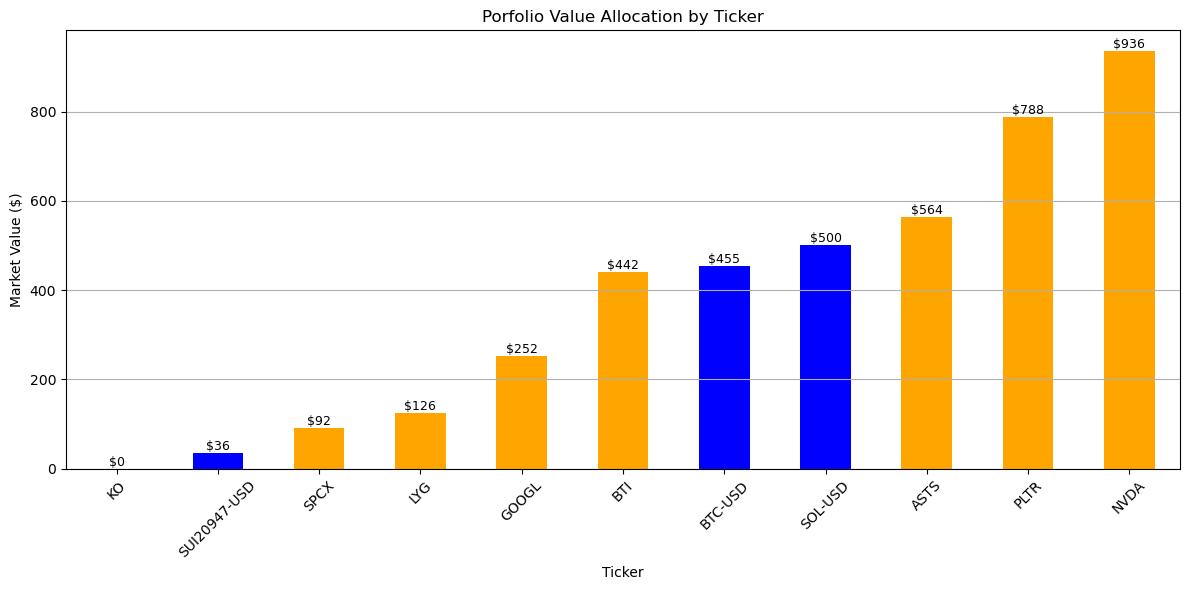

In [57]:
# Color ticker by asset
colors = [
    "orange" if ticker_asset_type[ticker] == "Equity" else "blue"
    for ticker in latest_positions.sort_values(ascending=True).index
]

# Distribution by ticker (Bar Chart - Value)
plt.figure(figsize=(12,6))
latest_positions.sort_values(ascending=True).plot(
    kind="bar",
    color=colors
)

plt.title("Porfolio Value Allocation by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Market Value ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

sorted_val = latest_positions.sort_values(ascending=True)
for i, v in enumerate(sorted_val.values):
    plt.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

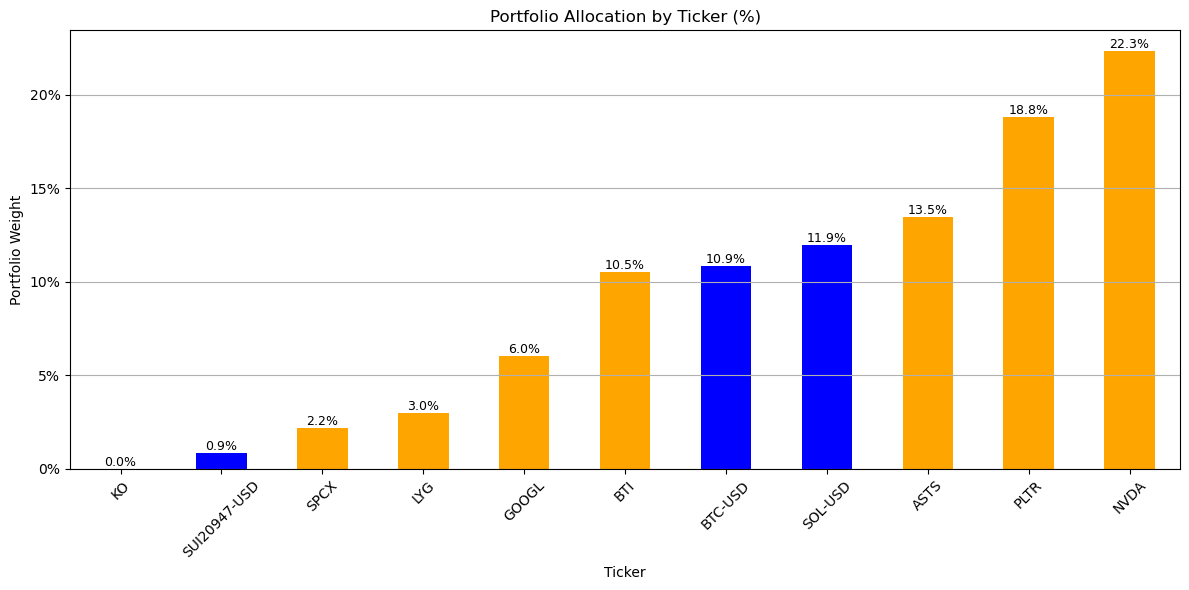

In [58]:
# Distribution by ticker (Bar Chart - %)
latest_positions_pct = latest_positions / latest_positions.sum()

# colors in the same sorted order as the bars
colors = [
    "orange" if ticker_asset_type[ticker] == "Equity" else "blue"
    for ticker in latest_positions_pct.sort_values(ascending=True).index
]

plt.figure(figsize=(12, 6))
latest_positions_pct.sort_values(ascending=True).plot(
    kind="bar",
    color=colors
)

plt.title("Portfolio Allocation by Ticker (%)")
plt.xlabel("Ticker")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

# format y-axis as percentages
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

sorted_pct = latest_positions_pct.sort_values(ascending=True)
for i, v in enumerate(sorted_pct.values):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_2032\1847303673.py:4: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(ticker_asset_type, axis=1)


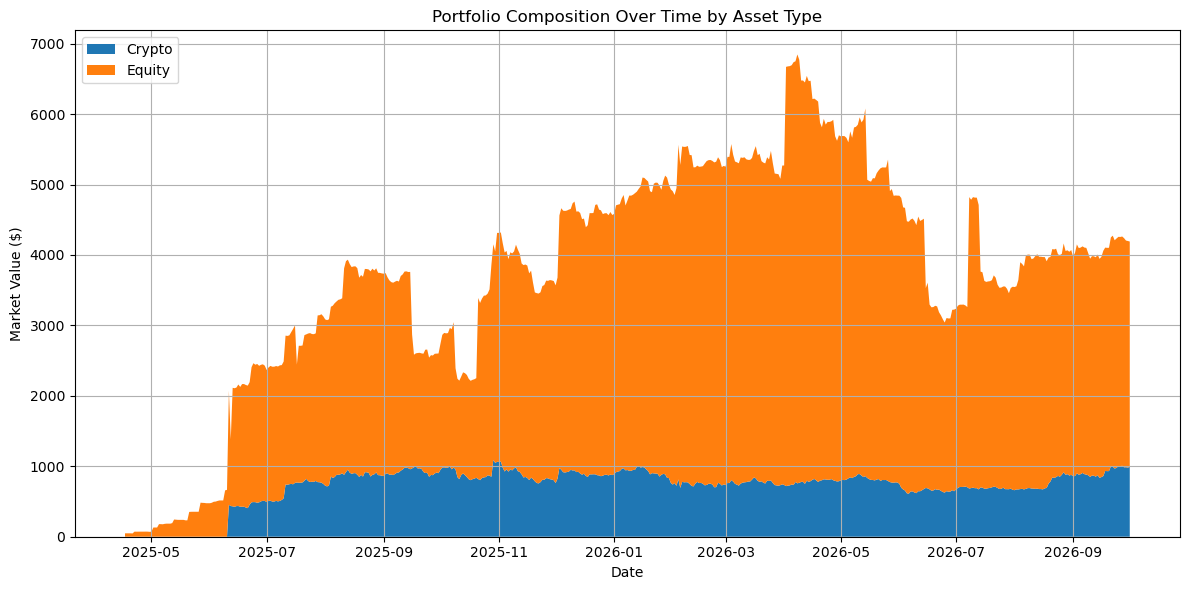

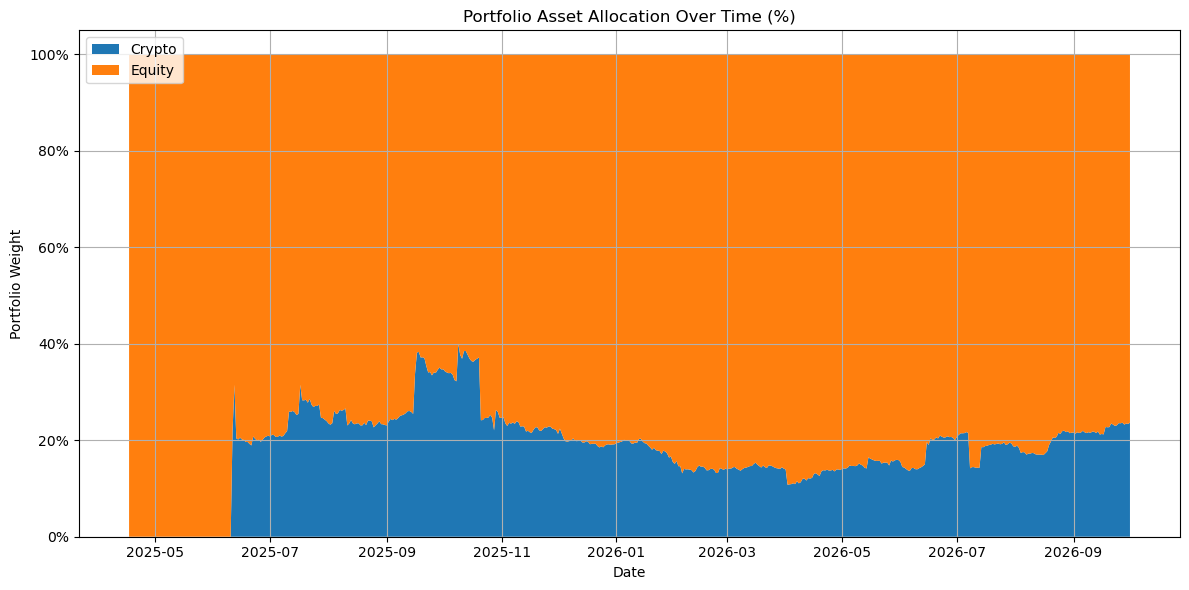

In [59]:
# Aggregate portfolio position values by Asset Type over time.
asset_type_over_time = (
    position_values
    .groupby(ticker_asset_type, axis=1)
    .sum()
)

# Plot portfolio composition over time using a stacked area chart.
plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_over_time.index,
    asset_type_over_time.T.values,
    labels=asset_type_over_time.columns
)

plt.title("Portfolio Composition Over Time by Asset Type")
plt.xlabel("Date")
plt.ylabel("Market Value ($)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot Stacked % Over time

# Convert market values to portfolio weights (row-wise)
asset_type_pct = asset_type_over_time.div(
    asset_type_over_time.sum(axis=1),
    axis=0
)
asset_type_pct = asset_type_pct.fillna(0)

plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_pct.index,
    asset_type_pct.T.values,
    labels=asset_type_pct.columns
)

plt.title("Portfolio Asset Allocation Over Time (%)")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(loc="upper left")
plt.grid(True)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()


# Profit and Loss

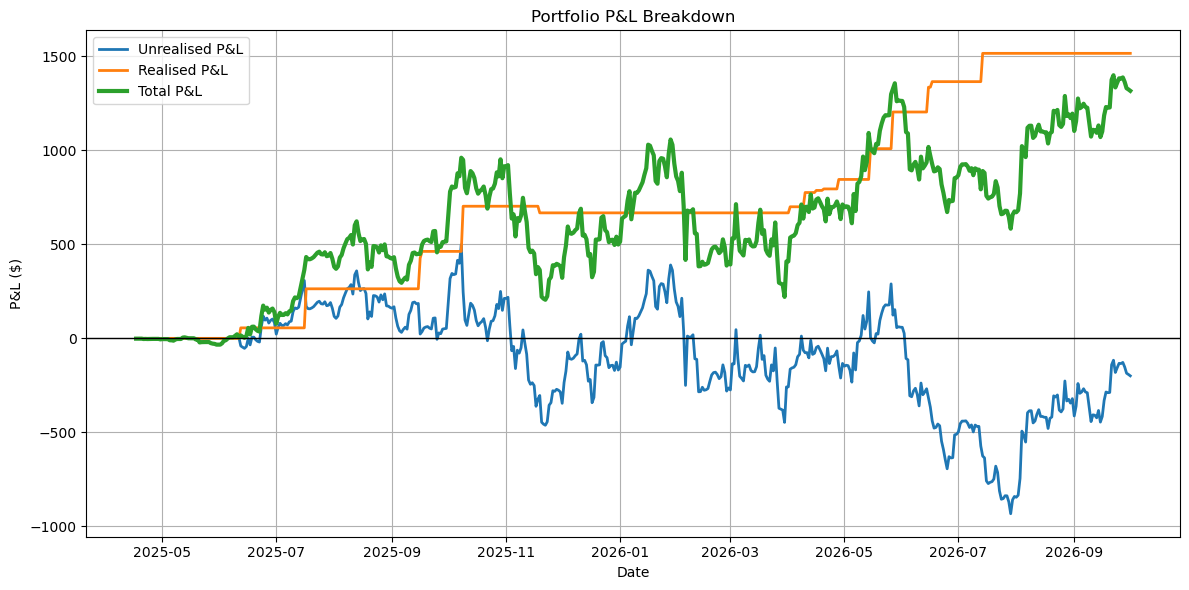

Current Unrealised G/L: $-199.4491194087368
Current Realised G/L: $1516.3210603623868
Total Current G/L: $1316.87194095365
Cost Basis G/L: $-199.4491194087368


In [60]:
# Unrealised PnL
unrealised_pnl = portfolio_value - portfolio_cost_basis

# Realised PnL
realised_df = pd.DataFrame(realised_records)

realised_pnl = (
    realised_df
    .groupby("Date")["Realised_PnL"]
    .sum()
    .reindex(prices.index, fill_value=0)
    .cumsum()
)

# Total PnL
total_pnl= realised_pnl + unrealised_pnl

# Plot
plt.figure(figsize=(12, 6))

plt.plot(unrealised_pnl, label="Unrealised P&L", linewidth=2)
plt.plot(realised_pnl, label="Realised P&L", linewidth=2)
plt.plot(total_pnl, label="Total P&L", linewidth=3)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio P&L Breakdown")
plt.xlabel("Date")
plt.ylabel("P&L ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Holding Basis G/L
cost_basis_gnl = portfolio_value - portfolio_cost_basis

# PnL
print(f"Current Unrealised G/L: ${unrealised_pnl.iloc[-1]}")
print(f"Current Realised G/L: ${realised_pnl.iloc[-1]}")
print(f"Total Current G/L: ${total_pnl.iloc[-1]}")
print(f"Cost Basis G/L: ${cost_basis_gnl.iloc[-1]}")

# Return over time

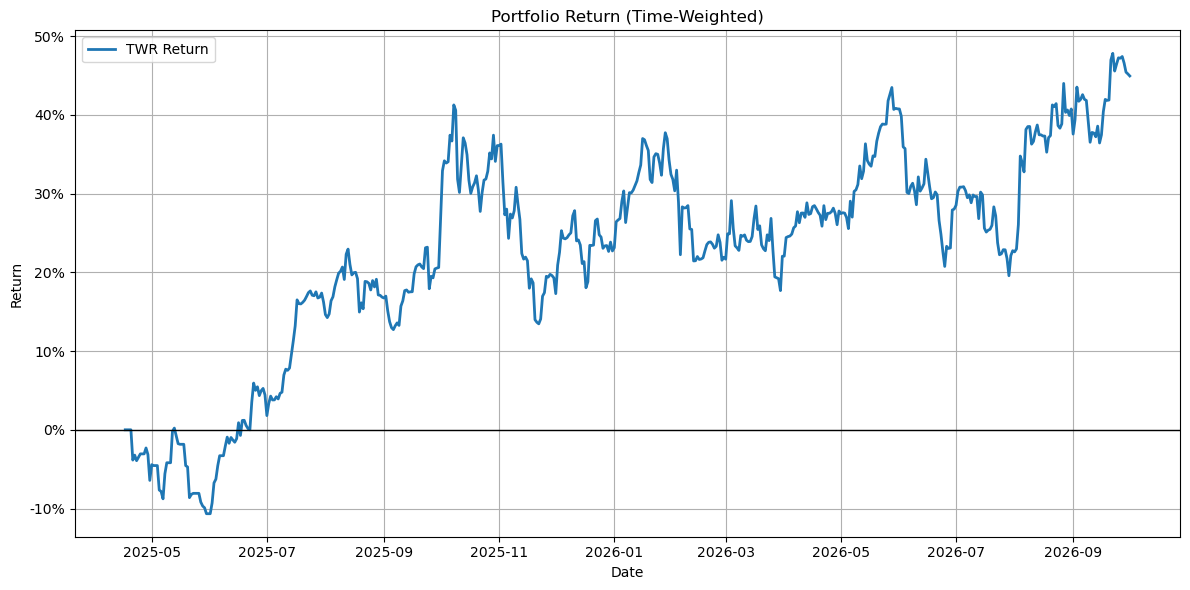

TWR: 44.93%


In [61]:
### TWR

# Daily Net CF
net_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(prices.index, fill_value=0)
)
# Reverse sign for TWR
net_cash_flow = -net_cash_flow

# TWR Return
portfolio_return = (
    (portfolio_value - (portfolio_value.shift(1) + net_cash_flow))
    / (portfolio_value.shift(1) + net_cash_flow)
)

# Clean numerical issues
portfolio_return = portfolio_return.replace([np.inf, -np.inf], 0).fillna(0)

# --------------------------
# Cumulative TWR
# --------------------------

cum_twr = (1 + portfolio_return).cumprod() - 1

# PLOT
plt.figure(figsize=(12,6))

plt.plot(cum_twr, label="TWR Return", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio Return (Time-Weighted)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"TWR: {cum_twr.iloc[-1]:.2%}")

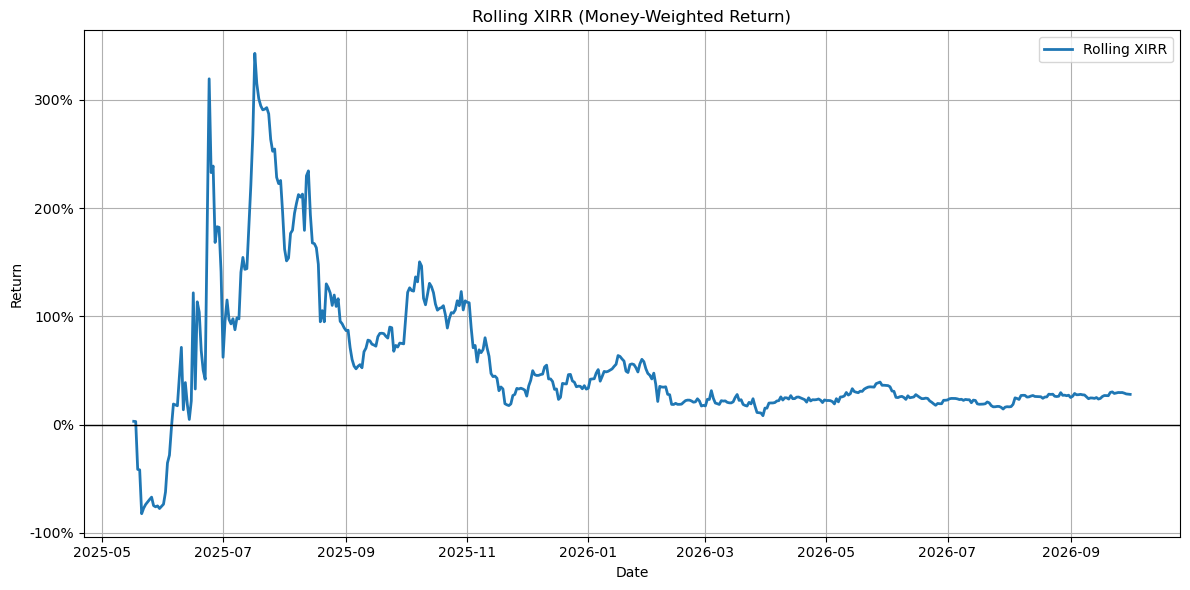

XIRR: 27.85%


In [62]:
### XIRR

# CF
cf = tx.groupby("Date")["cash_flow"].sum()

# Add final portfolio liquidation
cf = cf.copy()

# Add final liquidation value safely
final_date = portfolio_value.index[-1]
cf.loc[final_date] = cf.get(final_date, 0) + portfolio_value.iloc[-1]

cf = cf.sort_index()

# Convert dates to year
dates = cf.index
days = (dates - dates[0]).days / 365.25

# XIRR
def xirr(rate):
    return np.sum(cf.values / (1 + rate) ** days)

if (cf > 0).any() and (cf < 0).any():
    try:
        irr = brentq(xirr, -0.99, 10)
    except:
        irr = np.nan
else:
    irr = np.nan

# Over time
rolling_xirr = []

for i in range(30, len(portfolio_value)):
    
    # Build sub cash flow
    sub_cf = tx[tx["Date"] <= portfolio_value.index[i]]
    sub_cf = sub_cf.groupby("Date")["cash_flow"].sum().copy()
    
    date_i = portfolio_value.index[i]
    
    # Safe addition of portfolio value
    sub_cf.loc[date_i] = sub_cf.get(date_i, 0) + portfolio_value.iloc[i]
    
    sub_cf = sub_cf.sort_index()
    
    dates = sub_cf.index
    days = (dates - dates[0]).days / 365.25
    
    def f(rate):
        return np.sum(sub_cf.values / (1 + rate) ** days)
    
    # Ensure valid IRR inputs
    if (sub_cf > 0).any() and (sub_cf < 0).any():
        try:
            r = brentq(f, -0.99, 10)
        except:
            r = np.nan
    else:
        r = np.nan
    
    rolling_xirr.append(r)

rolling_xirr = pd.Series(
    rolling_xirr,
    index=portfolio_value.index[30:]
)

rolling_xirr = rolling_xirr.ffill()


# Plot
plt.figure(figsize=(12,6))

plt.plot(rolling_xirr, label="Rolling XIRR", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Rolling XIRR (Money-Weighted Return)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"XIRR: {irr:.2%}")

# PNL BY ASSET

In [63]:
# Latest and previous prices
last_prices = prices.iloc[-1]
prev_prices = prices.shift(1).iloc[-1]

# Optional: total dividend income by ticker
if "dividends_received_df" in locals():
    div_by_ticker = (
        dividends_received_df.groupby("Ticker")["Dividend_Received"]
        .sum()
    )
else:
    div_by_ticker = pd.Series(dtype=float)

# Sort transactions for inventory accounting
tx_summary = tx.sort_values(["Ticker", "Date"]).copy()

summary_records = []

for ticker, df in tx_summary.groupby("Ticker"):
    df = df.sort_values("Date")

    shares_held = 0.0
    cost_basis_open = 0.0

    realised_gain_usd = 0.0
    realised_cost_basis_sold = 0.0

    for _, row in df.iterrows():
        trade_type = row["Type"]
        qty = float(row["Shares"])
        px = float(row["Cost/Share ($)"])
        comm = float(row["Commn"]) if "Commn" in row and pd.notna(row["Commn"]) else 0.0

        if trade_type == "BUY":
            # Add shares and include buy commission in open cost basis
            shares_held += qty
            cost_basis_open += qty * px + comm

        elif trade_type == "SELL":
            if shares_held <= 0:
                continue

            avg_cost = cost_basis_open / shares_held

            # Cost basis of the sold shares
            sold_cost_basis = avg_cost * qty

            # Realised gain: proceeds - sold cost basis - sell commission
            realised_trade_gain = (qty * px) - sold_cost_basis - comm

            realised_gain_usd += realised_trade_gain
            realised_cost_basis_sold += sold_cost_basis

            # Remove sold inventory from open position
            shares_held -= qty
            cost_basis_open -= sold_cost_basis

            # Clean tiny floating point residue
            if abs(shares_held) < 1e-12:
                shares_held = 0.0
                cost_basis_open = 0.0

    # Current market data
    last_price = float(last_prices.get(ticker, 0.0))
    prev_price = float(prev_prices.get(ticker, last_price))

    market_value = shares_held * last_price
    prev_market_value = shares_held * prev_price

    # Average cost of remaining open shares
    ac_per_share = cost_basis_open / shares_held if shares_held > 0 else 0.0

    # Unrealised day gain
    day_gain_unrl_usd = shares_held * (last_price - prev_price)
    day_gain_unrl_pct = (
        day_gain_unrl_usd / prev_market_value
        if prev_market_value != 0 else 0.0
    )

    # Total unrealised gain
    tot_gain_unrl_usd = market_value - cost_basis_open
    tot_gain_unrl_pct = (
        tot_gain_unrl_usd / cost_basis_open
        if cost_basis_open != 0 else 0.0
    )

    # Realised gain %
    realised_gain_pct = (
        realised_gain_usd / realised_cost_basis_sold
        if realised_cost_basis_sold != 0 else 0.0
    )

    # Dividend income
    tot_div_income = float(div_by_ticker.get(ticker, 0.0))

    summary_records.append({
        "Ticker": ticker,
        "Shares": shares_held,
        "Last price": last_price,
        "AC/share": ac_per_share,
        "Total cost (US$)": cost_basis_open,
        "Market value (US$)": market_value,
        "Tot div income (US$)": tot_div_income,
        "Day gain UNRL (%)": day_gain_unrl_pct,
        "Day gain UNRL (US$)": day_gain_unrl_usd,
        "Tot gain UNRL (%)": tot_gain_unrl_pct,
        "Tot gain UNRL (US$)": tot_gain_unrl_usd,
        "Realised gain (%)": realised_gain_pct,
        "Realised gain (US$)": realised_gain_usd
    })

summary_df = pd.DataFrame(summary_records)

# Keep only assets currently held
summary_df = summary_df[summary_df["Shares"] > 0].copy()

# Sort by market value descending
summary_df = summary_df.sort_values("Market value (US$)", ascending=False).reset_index(drop=True)

In [64]:
# Keep raw summary_df for calculations
summary_display = summary_df.copy()

# Money columns -> 2 decimals
money_cols = [
    "Last price",
    "AC/share",
    "Total cost (US$)",
    "Market value (US$)",
    "Tot div income (US$)",
    "Day gain UNRL (US$)",
    "Tot gain UNRL (US$)",
    "Realised gain (US$)"
]

# Percentage columns -> 2 decimal places
pct_cols = [
    "Day gain UNRL (%)",
    "Tot gain UNRL (%)",
    "Realised gain (%)"
]

# Format for display
for col in money_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"${x:,.2f}")

for col in pct_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

# Keep shares precise
summary_display["Shares"] = summary_display["Shares"].map(lambda x: f"{x:,.6f}")

summary_display

,Ticker,Shares,Last price,AC/share,Total cost (US$),Market value (US$),Tot div income (US$),Day gain UNRL (%),Day gain UNRL (US$),Tot gain UNRL (%),Tot gain UNRL (US$),Realised gain (%),Realised gain (US$)
0,NVDA,4.053247,$230.86,$185.96,$753.73,$935.73,$2.02,1.09%,$10.05,24.15%,$182.01,20.76%,$180.25
1,PLTR,4.146839,$190.04,$150.36,$623.52,$788.07,$0.00,1.60%,$12.40,26.39%,$164.55,22.42%,$71.43
2,ASTS,9.889525,$57.04,$73.66,$728.51,$564.10,$0.00,-3.09%,$-18.00,-22.57%,$-164.41,40.37%,$710.05
3,SOL-USD,4.225896,$118.40,$130.68,$552.23,$500.34,$0.00,0.34%,$1.70,-9.40%,$-51.89,0.00%,$0.00
4,BTC-USD,0.005359,"$84,853.10","$109,330.52",$585.90,$454.73,$0.00,1.55%,$6.96,-22.39%,$-131.17,0.00%,$0.00
5,BTI,8.303943,$53.19,$59.10,$490.73,$441.69,$28.94,-2.22%,$-10.05,-9.99%,$-49.04,12.02%,$166.61
6,GOOGL,0.745557,$338.24,$353.98,$263.92,$252.18,$0.67,-1.70%,$-4.35,-4.45%,$-11.74,12.38%,$29.47
7,LYG,23.215480,$5.42,$5.85,$135.90,$125.83,$26.99,-3.73%,$-4.88,-7.41%,$-10.08,11.80%,$92.27
8,SPCX,0.621864,$148.07,$201.01,$125.00,$92.08,$0.00,-1.85%,$-1.73,-26.34%,$-32.92,0.00%,$0.00
9,SUI20947-USD,30.757090,$1.18,$4.26,$130.91,$36.16,$0.00,1.09%,$0.39,-72.38%,$-94.75,0.00%,$0.00


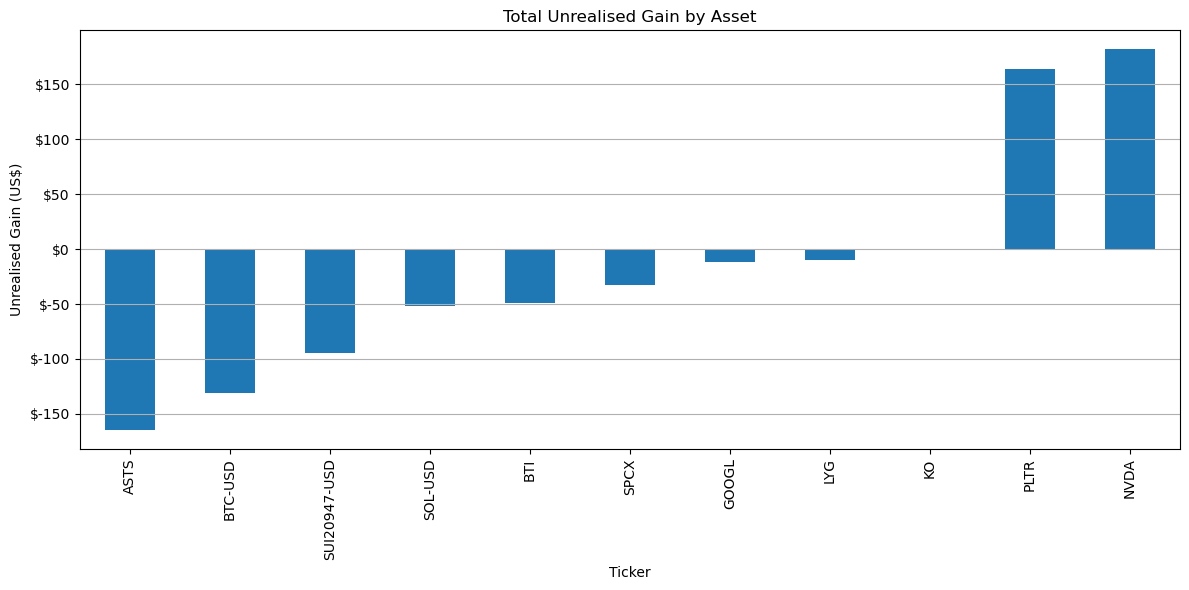

In [65]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Tot gain UNRL (US$)"].sort_values().plot(kind="bar")

plt.title("Total Unrealised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Unrealised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

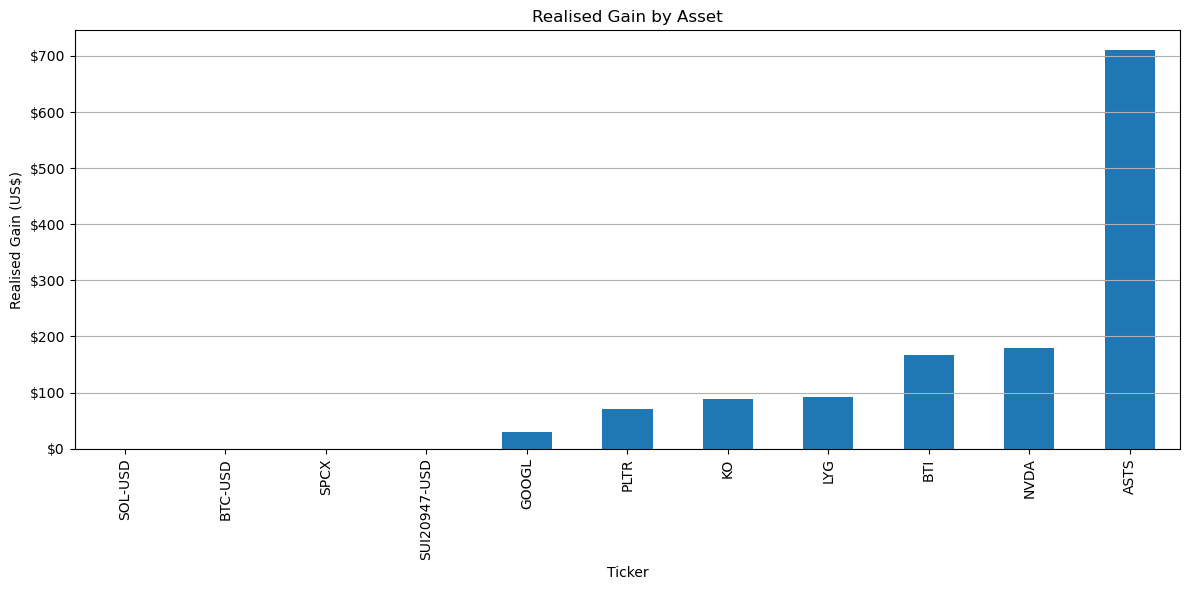

In [66]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Realised gain (US$)"].sort_values().plot(kind="bar")

plt.title("Realised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Realised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# Realised P&L per SELL order
# ============================================================
# Average-cost method, consistent with the cost-basis loop above.
# Commission handling: buy commissions are added to cost basis;
# sell commissions are netted out of proceeds.

tx_sorted = tx.sort_values(["Ticker", "Date"]).copy()

sell_pnl_records = []

for ticker, df in tx_sorted.groupby("Ticker"):
    df = df.sort_values("Date")

    shares = 0.0          # running shares held
    cost   = 0.0          # running cost basis (incl. buy commissions)

    for _, row in df.iterrows():
        qty   = float(row["Shares"])
        px    = float(row["Cost/Share ($)"])
        comm  = float(row["Commn"]) if pd.notna(row["Commn"]) else 0.0
        proceeds = float(row["Total Cost/Credit ($)"])   # net credit on the sell

        if row["Type"] == "BUY":
            shares += qty
            cost   += qty * px + comm

        elif row["Type"] == "SELL":
            if shares <= 0:
                # Sell with no recorded position — flag and skip
                sell_pnl_records.append({
                    "Date": row["Date"], "Ticker": ticker,
                    "Shares Sold": qty, "Sell Price": px,
                    "Proceeds (net)": proceeds,
                    "Avg Cost/Share": np.nan, "Cost of Shares Sold": np.nan,
                    "Realised P&L ($)": np.nan, "Return (%)": np.nan,
                    "Note": "No open position"
                })
                continue

            avg_cost      = cost / shares
            qty_sold      = min(qty, shares)          # guard against over-selling
            cost_removed  = avg_cost * qty_sold
            realised      = proceeds - cost_removed
            ret_pct       = realised / cost_removed if cost_removed else np.nan

            sell_pnl_records.append({
                "Date": row["Date"],
                "Ticker": ticker,
                "Shares Sold": qty_sold,
                "Sell Price": px,
                "Proceeds (net)": proceeds,
                "Avg Cost/Share": avg_cost,
                "Cost of Shares Sold": cost_removed,
                "Realised P&L ($)": realised,
                "Return (%)": ret_pct,
                "Note": ""
            })

            shares -= qty_sold
            cost   -= cost_removed
            if abs(shares) < 1e-12:
                shares, cost = 0.0, 0.0

sell_pnl_df = pd.DataFrame(sell_pnl_records).sort_values("Date").reset_index(drop=True)

# Readable display copy
disp = sell_pnl_df.copy()
for c in ["Sell Price", "Proceeds (net)", "Avg Cost/Share", "Cost of Shares Sold", "Realised P&L ($)"]:
    disp[c] = disp[c].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "—")
disp["Shares Sold"] = disp["Shares Sold"].map(lambda x: f"{x:,.6f}")
disp["Return (%)"]  = disp["Return (%)"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")

display(disp.tail(5))
print(f"\nTotal realised P&L across all sells: ${sell_pnl_df['Realised P&L ($)'].sum():,.2f}")

,Date,Ticker,Shares Sold,Sell Price,Proceeds (net),Avg Cost/Share,Cost of Shares Sold,Realised P&L ($),Return (%),Note
18,2026-06-15,LYG,160.000000,$5.48,$874.55,$4.89,$782.28,$92.27,11.80%,
19,2026-06-17,GOOGL,0.726624,$369.28,$267.64,$327.77,$238.16,$29.47,12.38%,
20,2026-07-14,NVDA,1.254458,$208.27,$260.60,$185.96,$233.27,$27.32,11.71%,
21,2026-07-14,KO,6.813016,$84.26,$572.61,$72.79,$495.93,$76.69,15.46%,
22,2026-07-14,FANG,1.085530,$193.56,$209.58,$150.21,$163.06,$46.52,28.53%,



Total realised P&L across all sells: $1,516.32


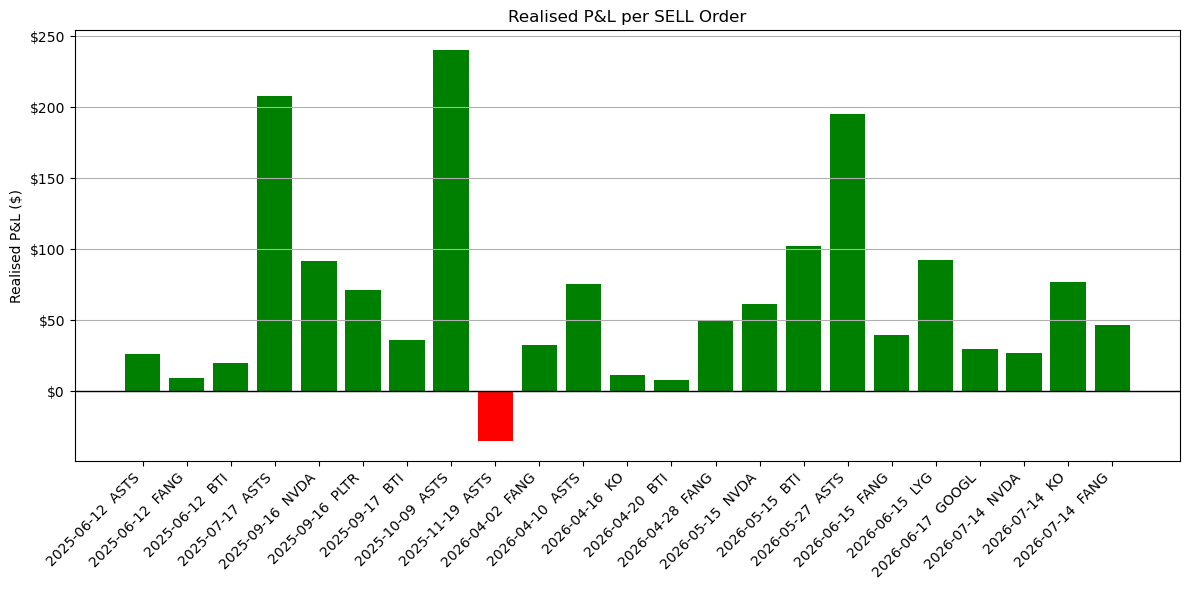

In [68]:
plt.figure(figsize=(12, 6))
labels = sell_pnl_df["Date"].dt.strftime("%Y-%m-%d") + "  " + sell_pnl_df["Ticker"]
colors = ["green" if v >= 0 else "red" for v in sell_pnl_df["Realised P&L ($)"].fillna(0)]

plt.bar(range(len(sell_pnl_df)), sell_pnl_df["Realised P&L ($)"].fillna(0), color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(range(len(sell_pnl_df)), labels, rotation=45, ha="right")
plt.title("Realised P&L per SELL Order")
plt.ylabel("Realised P&L ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Dividends

In [69]:
# DIV history for each ticker
dividend_records = []

for ticker in filt_tickers:
    try:
        div_series = yf.Ticker(ticker).dividends

        if div_series.empty:
            continue

        div_df = div_series.reset_index()
        div_df.columns = ["Date", "Dividend_per_share"]
        div_df["Ticker"] = ticker

        dividend_records.append(div_df)

    except Exception as e:
        print(f"Could not download dividends for {ticker}: {e}")

# Combine all dividend histories
if dividend_records:
    dividends_df = pd.concat(dividend_records, ignore_index=True)
else:
    dividends_df = pd.DataFrame(columns=["Date", "Dividend_per_share", "Ticker"])

dividends_df["Date"] = pd.to_datetime(dividends_df["Date"])
dividends_df = dividends_df.sort_values(["Ticker", "Date"])
dividends_df["Date"] = pd.to_datetime(dividends_df["Date"]).dt.tz_localize(None).dt.normalize()
tx["Date"] = pd.to_datetime(tx["Date"]).dt.normalize()
daily_holdings.index = pd.to_datetime(daily_holdings.index).normalize()

In [70]:
# Determine the number of shares held on each div date
dividend_records_with_shares = []


for _, row in dividends_df.iterrows():
    ticker = row["Ticker"]
    div_date = row["Date"]

    # If ticker exists in daily_holdings and date exists in index
    if ticker in daily_holdings.columns and div_date in daily_holdings.index:
        shares_held = daily_holdings.loc[div_date, ticker]
    else:
        shares_held = 0

    dividend_records_with_shares.append(shares_held)

dividends_df["Shares_Held"] = dividend_records_with_shares

In [71]:
# Compute div received
# ------------------------------------------------------------
# Dividend received = dividend per share × shares held
# ------------------------------------------------------------
dividends_df["Dividend_Received"] = (
    dividends_df["Dividend_per_share"] * dividends_df["Shares_Held"]
)

# Keep only positive dividend receipts
dividends_received_df = dividends_df[dividends_df["Dividend_Received"] > 0].copy()

In [72]:
# Total Div Received
monthly_dividends = (
    dividends_received_df
    .groupby(dividends_received_df["Date"].dt.to_period("M"))["Dividend_Received"]
    .sum()
)

monthly_dividends.index = monthly_dividends.index.to_timestamp()
monthly_dividend_table = monthly_dividends.to_frame(name="Monthly_Dividend_Received")
monthly_dividend_table["Cumulative_Dividends"] = monthly_dividend_table["Monthly_Dividend_Received"].cumsum()

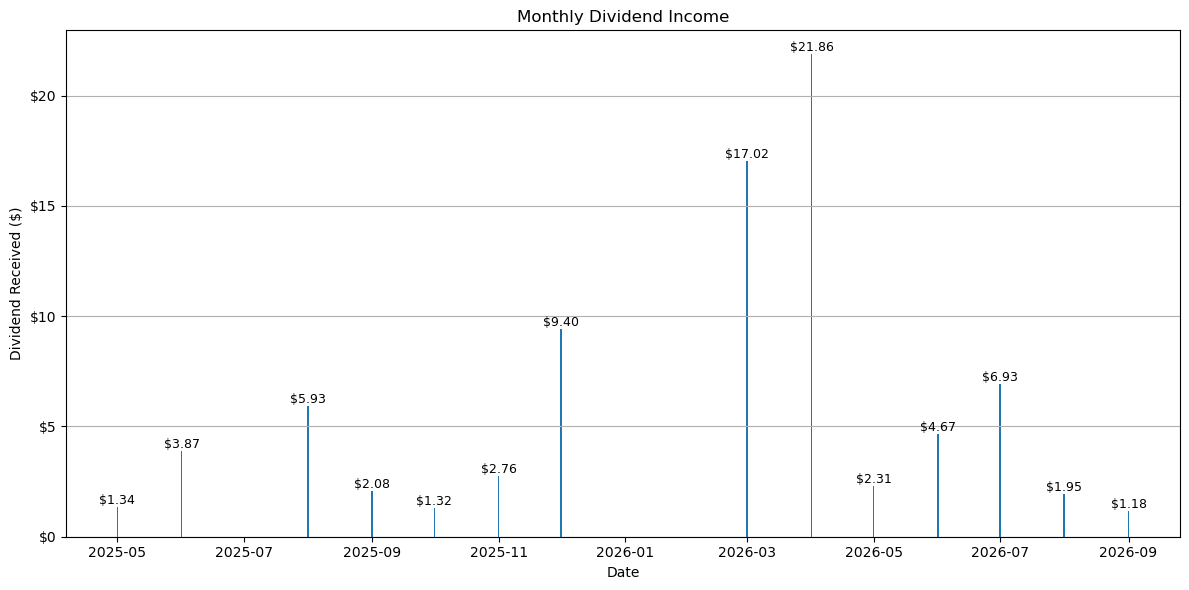

Total Dividends Received: $82.65


In [73]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_dividends.index,
    monthly_dividends.values
)

plt.title("Monthly Dividend Income")
plt.xlabel("Date")
plt.ylabel("Dividend Received ($)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Value labels
for x, y in zip(monthly_dividends.index, monthly_dividends.values):
    if y > 0:
        plt.text(
            x,
            y,
            f"${y:,.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

# Total div
total_dividends = dividends_received_df["Dividend_Received"].sum()
print(f"Total Dividends Received: ${total_dividends:,.2f}")

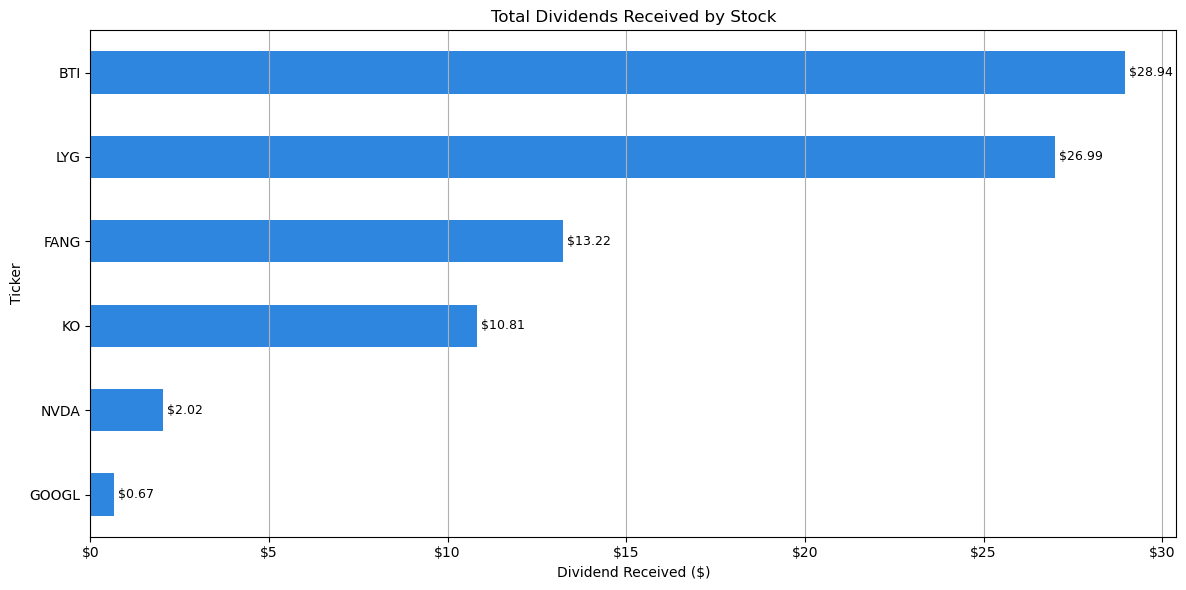

Total dividends received: $82.65


In [74]:
# Dividend received by stock (total to date)
dividends_by_ticker = (
    dividends_received_df
    .groupby("Ticker")["Dividend_Received"]
    .sum()
    .sort_values(ascending=True)        # ascending so largest sits at the top of a horizontal bar
)

plt.figure(figsize=(12, 6))
dividends_by_ticker.plot(kind="barh", color="#2e86de")

plt.title("Total Dividends Received by Stock")
plt.xlabel("Dividend Received ($)")
plt.ylabel("Ticker")
plt.grid(True, axis="x")
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# value labels at the end of each bar
for i, v in enumerate(dividends_by_ticker.values):
    plt.text(v, i, f" ${v:,.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total dividends received: ${dividends_by_ticker.sum():,.2f}")

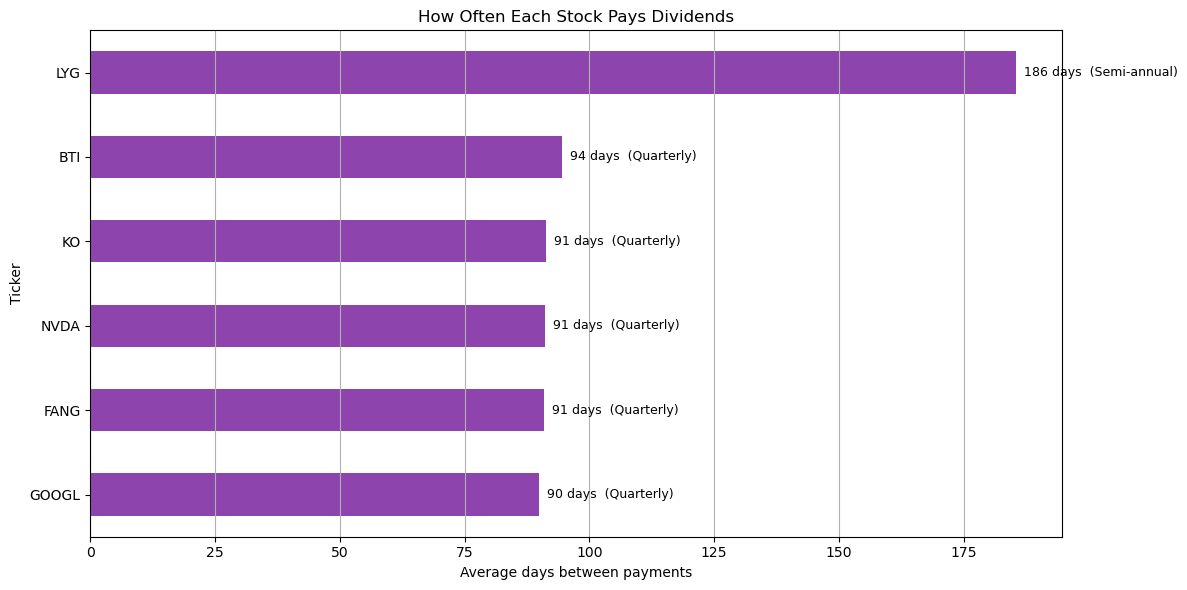

In [75]:
# How often each ticker pays a dividend (avg days between payouts)
cadence = (
    dividends_received_df
    .sort_values(["Ticker", "Date"])
    .groupby("Ticker")["Date"]
    .apply(lambda d: d.diff().dt.days.mean())
    .dropna()
    .sort_values(ascending=True)        # most frequent at the top
)

# Translate days into a human label
def cadence_label(days):
    if days < 45:    return "Monthly"
    if days < 135:   return "Quarterly"
    if days < 250:   return "Semi-annual"
    return "Annual"

plt.figure(figsize=(12, 6))
cadence.plot(kind="barh", color="#8e44ad")

plt.title("How Often Each Stock Pays Dividends")
plt.xlabel("Average days between payments")
plt.ylabel("Ticker")
plt.grid(True, axis="x")

for i, (ticker, days) in enumerate(cadence.items()):
    plt.text(days, i, f"  {days:.0f} days  ({cadence_label(days)})",
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

# OPTIMISATION

Growth budget: $926.92
Income budget: $617.95

=== Growth sleeve (Sortino, actively traded) ===
SOL-USD         55.2 %
PLTR            28.6 %
BTC-USD         12.0 %
SUI20947-USD     4.2 %
ASTS             0.0 %
SPCX             0.0 %
NVDA             0.0 %
Expected return 109.6%, total vol 38.3%

=== Income sleeve (min-var, hold for dividends) ===
KO       50.2 %
GOOGL    17.4 %
LYG      16.3 %
BTI      16.1 %
Expected return 17.1%, vol 11.4%

=== Buy orders for $1,544.87 ===
              Sleeve    Buy $  Last price   Shares
SOL-USD       Growth  $511.61     $118.40   4.3211
PLTR          Growth  $265.54     $190.04   1.3973
BTC-USD       Growth  $111.07  $84,853.10   0.0013
SUI20947-USD  Growth   $38.71       $1.18  32.9267
KO            Income  $310.35      $86.10   3.6046
GOOGL         Income  $107.79     $338.24   0.3187
LYG           Income  $100.43       $5.42  18.5301
BTI           Income   $99.38      $53.19   1.8683

Total deployed: $1,544.87


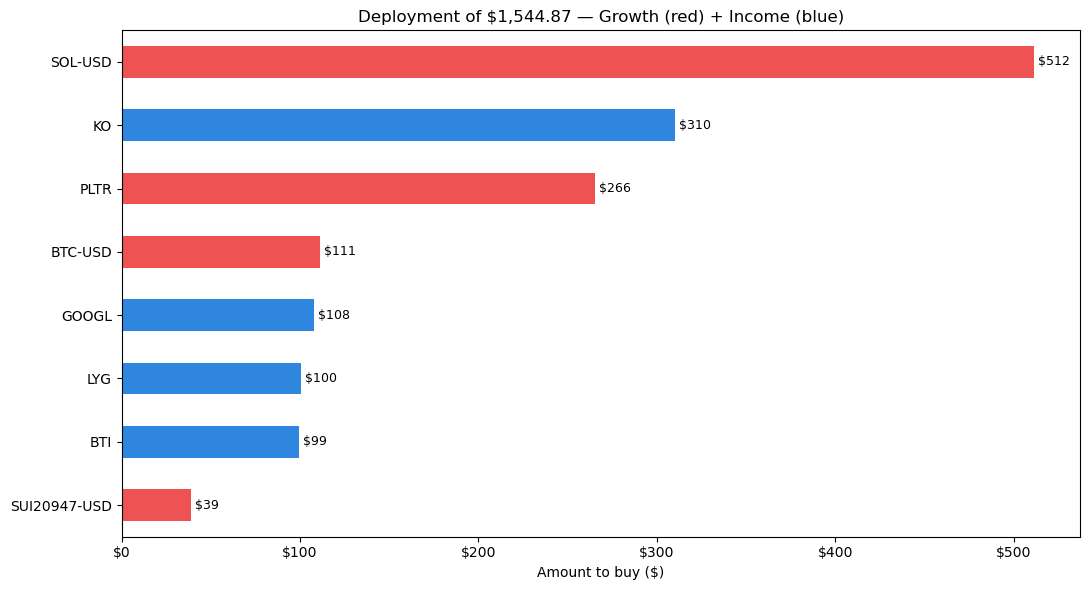

In [76]:
# ============================================================
# Deploy $1,475.42 — 70% growth (Sortino, active) / 30% income (min-var, hold)
# ============================================================
# Picks up from: tx, prices, summary_df, portfolio_value

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

# ---------------- config ----------------
cash_to_deploy = 1156.60 * 1.3357
growth_split   = 0.60
income_split   = 1 - growth_split

risk_free      = 0.045
trading_days   = 252
income_tickers = ["KO", "BTI", "LYG", "GOOGL"]

# Per-sleeve cash budget
growth_budget = cash_to_deploy * growth_split
income_budget = cash_to_deploy * income_split
print(f"Growth budget: ${growth_budget:,.2f}")
print(f"Income budget: ${income_budget:,.2f}\n")

# ---------------- classify holdings ----------------
held          = summary_df["Ticker"].tolist()
income_assets = [t for t in income_tickers if t in held]
growth_assets = [t for t in held if t not in income_assets]

# ---------------- shared helpers ----------------
def get_returns(tickers):
    px   = prices[tickers].copy().replace(0, np.nan).dropna()
    return np.log(px / px.shift(1)).dropna()

def optimise_sortino(tickers, target=0.0):
    """Max Sortino: returns per unit of DOWNSIDE volatility only.
       Right for actively-traded sleeve — upside swings aren't risk."""
    rets = get_returns(tickers)
    mu   = rets.mean() * trading_days
    # Downside semi-covariance: zero out returns above target before covariance
    downside = rets.where(rets < target, 0)
    dcov = LedoitWolf().fit(downside).covariance_ * trading_days
    assets, n = rets.columns.tolist(), len(rets.columns)

    def neg_sortino(w):
        d_vol = np.sqrt(w @ dcov @ w)
        return -((w @ mu.values) - risk_free) / d_vol if d_vol > 0 else 0.0

    res = minimize(neg_sortino, np.repeat(1/n, n), method="SLSQP",
                   bounds=tuple((0.0, 1.0) for _ in range(n)),
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                   options={"maxiter": 1000, "ftol": 1e-10})
    w = pd.Series(res.x, index=assets).clip(lower=0)
    return w / w.sum(), mu, np.cov(rets.T) * trading_days

def optimise_minvar(tickers):
    """Min variance: right for buy-and-hold income sleeve."""
    rets = get_returns(tickers)
    cov  = LedoitWolf().fit(rets).covariance_ * trading_days
    mu   = rets.mean() * trading_days
    assets, n = rets.columns.tolist(), len(rets.columns)

    res = minimize(lambda w: w @ cov @ w, np.repeat(1/n, n), method="SLSQP",
                   bounds=tuple((0.0, 1.0) for _ in range(n)),
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                   options={"maxiter": 1000, "ftol": 1e-10})
    w = pd.Series(res.x, index=assets).clip(lower=0)
    return w / w.sum(), mu, cov

# ---------------- optimise each sleeve ----------------
growth_weights, growth_mu, growth_cov = optimise_sortino(growth_assets)
income_weights, income_mu, income_cov = optimise_minvar(income_assets)

# ---------------- per-sleeve buy plan ----------------
last_price   = prices[growth_assets + income_assets].iloc[-1]

growth_buys = growth_weights * growth_budget
income_buys = income_weights * income_budget
all_buys    = pd.concat([growth_buys, income_buys])
all_buys    = all_buys[all_buys > 0.50]   # ignore dust < $0.50

orders = pd.DataFrame({
    "Sleeve":     ["Growth" if t in growth_assets else "Income" for t in all_buys.index],
    "Buy $":      all_buys,
    "Last price": last_price[all_buys.index],
    "Shares":     all_buys / last_price[all_buys.index],
}).sort_values(["Sleeve", "Buy $"], ascending=[True, False])

# ---------------- report ----------------
def sleeve_stats(w, mu, cov):
    return w @ mu.values, np.sqrt(w.values @ cov @ w.values)

g_ret, g_vol = sleeve_stats(growth_weights, growth_mu, growth_cov)
i_ret, i_vol = sleeve_stats(income_weights, income_mu, income_cov)

print("=== Growth sleeve (Sortino, actively traded) ===")
print((growth_weights.sort_values(ascending=False)*100).round(1).astype(str).add(" %").to_string())
print(f"Expected return {g_ret:.1%}, total vol {g_vol:.1%}")

print("\n=== Income sleeve (min-var, hold for dividends) ===")
print((income_weights.sort_values(ascending=False)*100).round(1).astype(str).add(" %").to_string())
print(f"Expected return {i_ret:.1%}, vol {i_vol:.1%}")

print(f"\n=== Buy orders for ${cash_to_deploy:,.2f} ===")
disp = orders.copy()
disp["Buy $"]      = disp["Buy $"].map("${:,.2f}".format)
disp["Last price"] = disp["Last price"].map("${:,.2f}".format)
disp["Shares"]     = disp["Shares"].map("{:,.4f}".format)
print(disp.to_string())
print(f"\nTotal deployed: ${orders['Buy $'].sum():,.2f}")

# ---------------- chart ----------------
plt.figure(figsize=(11, 6))
chart_data = orders.set_index(orders.index)["Buy $"].sort_values()
colors = ["#2e86de" if orders.loc[t, "Sleeve"] == "Income" else "#ee5253" for t in chart_data.index]
chart_data.plot(kind="barh", color=colors)
plt.title(f"Deployment of ${cash_to_deploy:,.2f} — Growth (red) + Income (blue)")
plt.xlabel("Amount to buy ($)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(chart_data.values):
    plt.text(v, i, f" ${v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [77]:
# ---------------- current vs new weights ----------------
# Current = market values from summary_df
# New     = current market values + the buys above
current_value = summary_df.set_index("Ticker")["Market value (US$)"]

# Universe = everything currently held OR being bought
all_tickers   = sorted(set(current_value.index) | set(orders.index))
current_val   = current_value.reindex(all_tickers).fillna(0)
buy_val       = orders["Buy $"].reindex(all_tickers).fillna(0)
new_val       = current_val + buy_val

current_w = current_val / current_val.sum()
new_w     = new_val     / new_val.sum()

comparison = pd.DataFrame({
    "Sleeve":     ["Income" if t in income_assets else "Growth" for t in all_tickers],
    "Current %":  current_w,
    "New %":      new_w,
    "Δ(pp)":    (new_w - current_w) * 100,
    "Buy $":      buy_val,
}, index=all_tickers).sort_values("New %", ascending=False)

disp_cmp = comparison.copy()
disp_cmp["Current %"] = disp_cmp["Current %"].map("{:.1%}".format)
disp_cmp["New %"]     = disp_cmp["New %"].map("{:.1%}".format)
disp_cmp["Δ(pp)"]    = disp_cmp["Δ(pp)"].map("{:+.1f}".format)
disp_cmp["Buy $"]     = disp_cmp["Buy $"].map("${:,.2f}".format)

print("\n=== Current vs New weights (after the buy plan executes) ===")
print(disp_cmp.to_string())

# Sleeve-level rollup
cur_growth = current_w[[t for t in all_tickers if t in growth_assets]].sum()
cur_income = current_w[[t for t in all_tickers if t in income_assets]].sum()
new_growth = new_w[[t for t in all_tickers if t in growth_assets]].sum()
new_income = new_w[[t for t in all_tickers if t in income_assets]].sum()
print(f"\nSleeve totals: "
      f"Growth {cur_growth:.1%} -> {new_growth:.1%}, "
      f"Income {cur_income:.1%} -> {new_income:.1%}")


=== Current vs New weights (after the buy plan executes) ===
              Sleeve Current %  New % Δ(pp)    Buy $
PLTR          Growth     18.8%  18.4%  -0.4  $265.54
SOL-USD       Growth     11.9%  17.6%  +5.7  $511.61
NVDA          Growth     22.3%  16.3%  -6.0    $0.00
BTC-USD       Growth     10.9%   9.9%  -1.0  $111.07
ASTS          Growth     13.5%   9.8%  -3.6    $0.00
BTI           Income     10.5%   9.4%  -1.1   $99.38
GOOGL         Income      6.0%   6.3%  +0.3  $107.79
KO            Income      0.0%   5.4%  +5.4  $310.35
LYG           Income      3.0%   3.9%  +0.9  $100.43
SPCX          Growth      2.2%   1.6%  -0.6    $0.00
SUI20947-USD  Growth      0.9%   1.3%  +0.4   $38.71

Sleeve totals: Growth 80.4% -> 74.9%, Income 19.6% -> 25.1%


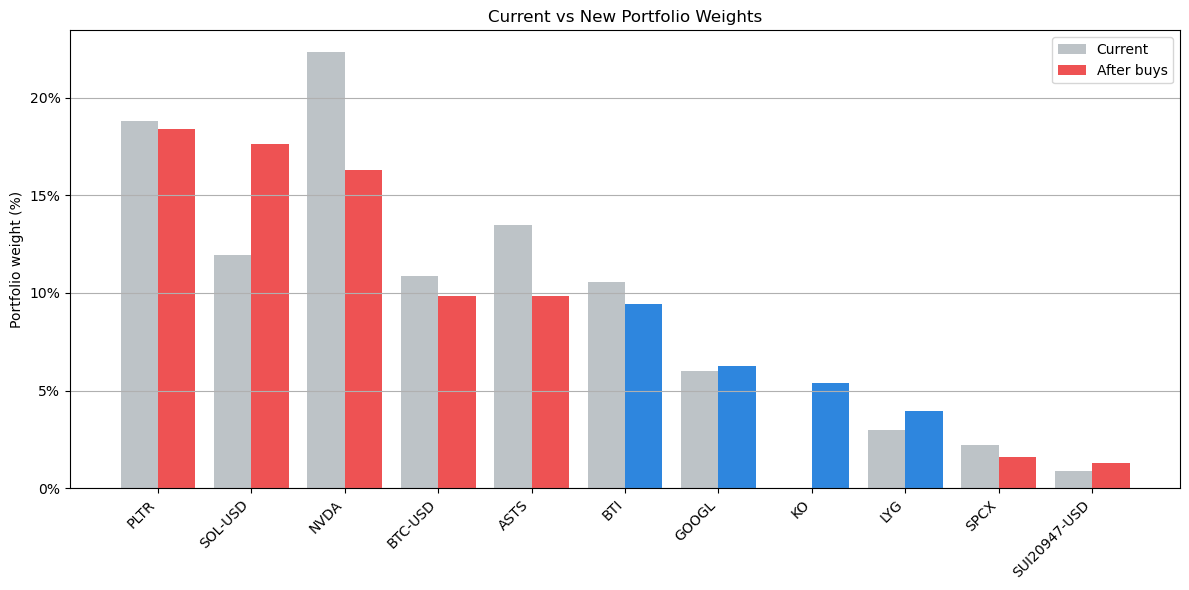

In [78]:
fig, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(comparison))
width  = 0.4

ax.bar(x - width/2, comparison["Current %"]*100, width, label="Current", color="#bdc3c7")
ax.bar(x + width/2, comparison["New %"]*100,     width,
       label="After buys",
       color=["#2e86de" if s == "Income" else "#ee5253" for s in comparison["Sleeve"]])

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha="right")
ax.set_ylabel("Portfolio weight (%)")
ax.set_title("Current vs New Portfolio Weights")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

# ACTUAL vs OPTIMISE

You sold in: ['2025-06', '2025-07', '2025-09', '2025-10', '2025-11', '2026-04', '2026-05', '2026-06', '2026-07']
Phase-2 mechanical rule starts: 2026-04-01



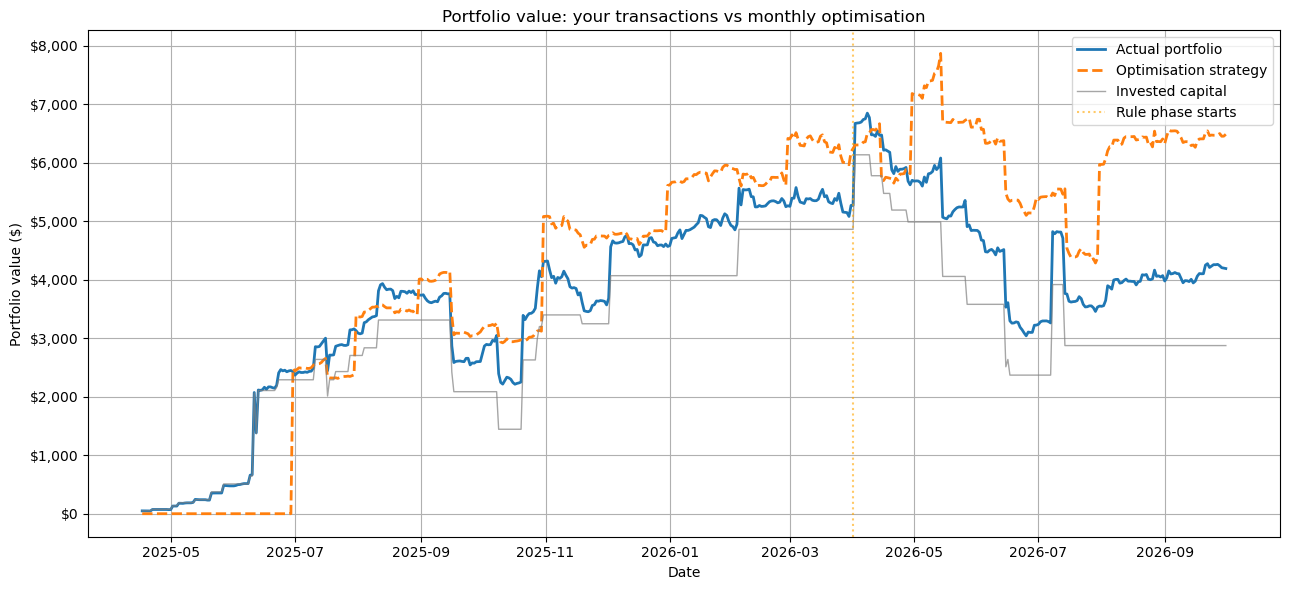

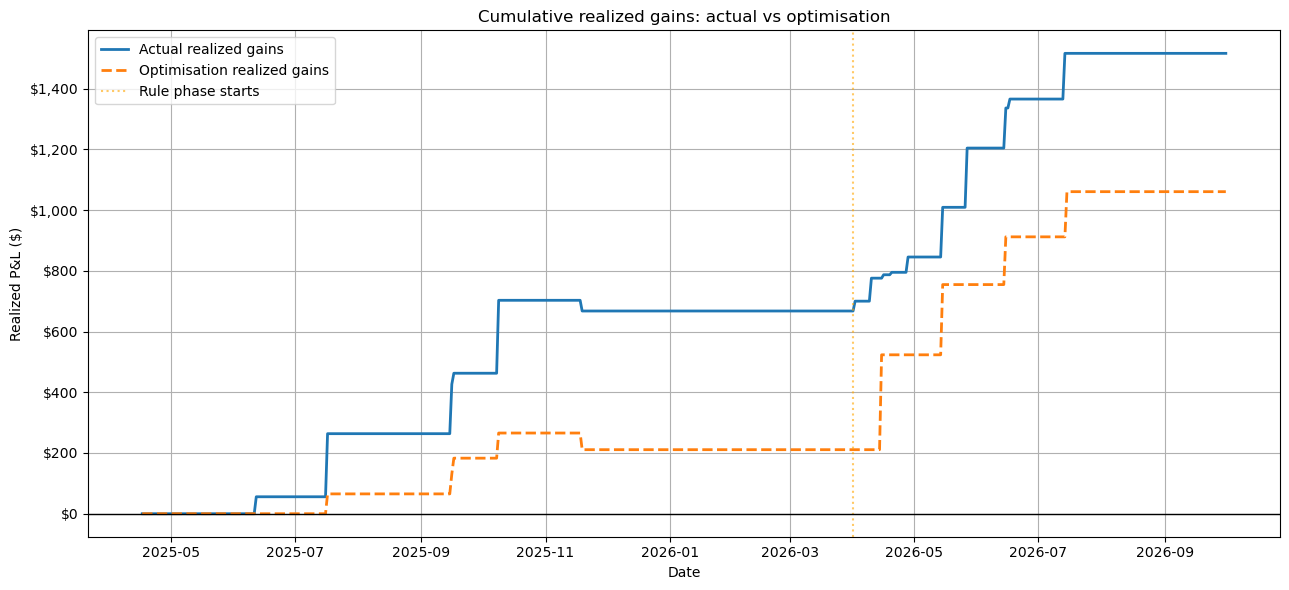

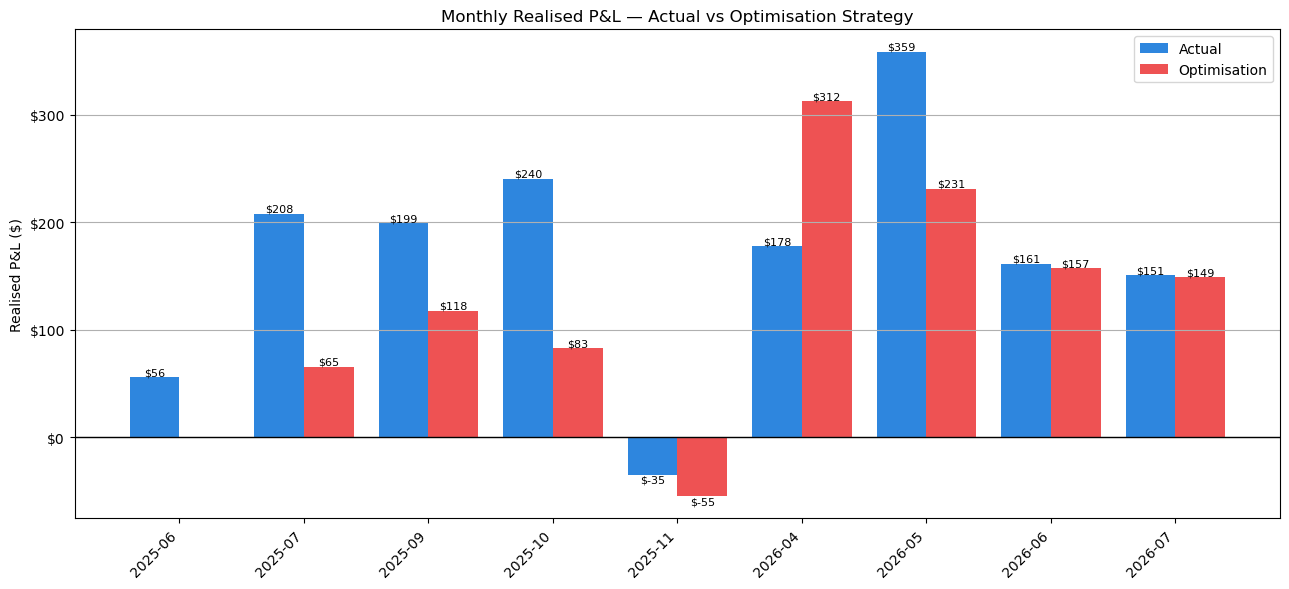

=== Backtest summary ===
Total invested:                         $2,874.02

Actual portfolio value:                 $4,190.89   (return +45.8%)
Optimisation portfolio value:           $6,485.48   (return +125.7%)
Value gap (you − optimiser):            $-2,294.59

Actual cumulative realized gains:       $1,516.32
Optimisation cumulative realized gains: $1,060.73
Realized gap (you − optimiser):         $+455.59

=== Monthly realized P&L ===
          Actual Optimisation Gap (Actual − Opt)
2025-06   $55.77        $0.00            $+55.77
2025-07  $207.83       $65.26           $+142.56
2025-09  $199.08      $117.66            $+81.42
2025-10  $240.24       $82.82           $+157.43
2025-11  $-35.25      $-54.85            $+19.60
2026-04  $177.83      $312.47           $-134.65
2026-05  $358.82      $231.33           $+127.49
2026-06  $161.47      $157.22             $+4.25
2026-07  $150.53      $148.82             $+1.71

=== Optimisation strategy sells (chronological) ===
      Date Ti

In [80]:
# ============================================================
# Backtest: optimisation strategy vs actual
# Buys:  end of each month, budget = actual monthly_spending
# Sells: 15th of each month
#   Phase 1 (before 2026-04): mirror your actual sells
#   Phase 2 (from  2026-04 ): $1,000 mechanical rule
# ============================================================

# ---------------- backtest config ----------------
sell_day         = 15
sell_target      = 1000.0
initial_trim_pct = 0.75
min_trim_pct     = 0.50
min_history_days = 60
rule_start       = pd.Timestamp("2026-04-01")   # phase-2 switch

universe = list(tx["Ticker"].unique())
income_set = set(income_tickers)

# ---------------- time-aware optimisation helpers ----------------
def returns_from(px_hist, tickers):
    px = px_hist[tickers].copy().replace(0, np.nan).dropna()
    return np.log(px / px.shift(1)).dropna()

def sortino_at(px_hist, tickers, target=0.0):
    rets = returns_from(px_hist, tickers)
    if len(rets) < 30 or len(tickers) < 2:
        return pd.Series(1/len(tickers), index=tickers)
    mu       = rets.mean() * trading_days
    downside = rets.where(rets < target, 0)
    dcov     = LedoitWolf().fit(downside).covariance_ * trading_days
    n        = len(rets.columns)
    def neg_sortino(w):
        d = np.sqrt(w @ dcov @ w)
        return -((w @ mu.values) - risk_free) / d if d > 0 else 0.0
    res = minimize(neg_sortino, np.repeat(1/n, n), method="SLSQP",
                   bounds=tuple((0.0, 1.0) for _ in range(n)),
                   constraints=[{"type": "eq", "fun": lambda w: w.sum()-1}],
                   options={"maxiter": 500, "ftol": 1e-9})
    w = pd.Series(res.x, index=rets.columns).clip(lower=0)
    return w / w.sum() if w.sum() > 0 else pd.Series(1/n, index=rets.columns)

def minvar_at(px_hist, tickers):
    rets = returns_from(px_hist, tickers)
    if len(rets) < 30 or len(tickers) < 2:
        return pd.Series(1/len(tickers), index=tickers)
    cov = LedoitWolf().fit(rets).covariance_ * trading_days
    n   = len(rets.columns)
    res = minimize(lambda w: w @ cov @ w, np.repeat(1/n, n), method="SLSQP",
                   bounds=tuple((0.0, 1.0) for _ in range(n)),
                   constraints=[{"type": "eq", "fun": lambda w: w.sum()-1}],
                   options={"maxiter": 500, "ftol": 1e-9})
    w = pd.Series(res.x, index=rets.columns).clip(lower=0)
    return w / w.sum() if w.sum() > 0 else pd.Series(1/n, index=rets.columns)

# ---------------- state (reset each run) ----------------
shadow_shares   = pd.Series(0.0, index=universe)
shadow_cost     = pd.Series(0.0, index=universe)
shadow_realised = []
snapshots       = {}

# months where you actually sold
actual_sell_months = set(
    tx[tx["Type"] == "SELL"]["Date"].dt.to_period("M")
)
print(f"You sold in: {sorted(str(m) for m in actual_sell_months)}")
print(f"Phase-2 mechanical rule starts: {rule_start.date()}\n")

months = monthly_spending.index

for month_end in months:
    target_day = pd.Timestamp(year=month_end.year, month=month_end.month, day=sell_day)
    trading_days_in_month = prices.index[
        (prices.index.year  == month_end.year) &
        (prices.index.month == month_end.month)
    ]

    # ==== 1. SELL: only on months when you actually sold ====
    if len(trading_days_in_month) > 0 and month_end.to_period("M") in actual_sell_months:

        # ---------- PHASE 1: mirror actual sells ----------
        if month_end < rule_start:
            month_period   = month_end.to_period("M")
            actual_sells_m = tx[
                (tx["Type"] == "SELL") &
                (tx["Date"].dt.to_period("M") == month_period)
            ]

            for _, row in actual_sells_m.iterrows():
                ticker           = row["Ticker"]
                real_shares_sold = float(row["Shares"])
                sell_dt          = row["Date"]
                sell_price       = float(row["Cost/Share ($)"])

                shares_held = shadow_shares[ticker]
                if shares_held <= 0 or sell_price <= 0:
                    continue

                shares_to_sell = min(real_shares_sold, shares_held)
                avg_cost       = shadow_cost[ticker] / shares_held
                proceeds       = shares_to_sell * sell_price
                cost_removed   = avg_cost * shares_to_sell
                realised       = proceeds - cost_removed

                shadow_realised.append({
                    "Date": sell_dt, "Ticker": ticker,
                    "Shares Sold": shares_to_sell, "Sell Price": sell_price,
                    "Proceeds": proceeds, "Cost of Shares Sold": cost_removed,
                    "Realised P&L": realised,
                    "Return %": realised / cost_removed if cost_removed else 0,
                    "Trim %": shares_to_sell / shares_held,
                    "Winner": (sell_price - avg_cost) > 0,
                    "Phase": "mirror",
                })
                shadow_shares[ticker] -= shares_to_sell
                shadow_cost[ticker]   -= cost_removed
                snapshots[sell_dt]    = shadow_shares.copy()

        # ---------- PHASE 2: $1,000 mechanical rule ----------
        else:
            sell_date = trading_days_in_month[
                np.argmin(np.abs((trading_days_in_month - target_day).days))
            ]
            sell_prices = prices.loc[sell_date]

            candidates = []
            for ticker in universe:
                shares = shadow_shares[ticker]
                if shares <= 0: continue
                price = sell_prices.get(ticker, 0)
                if price <= 0: continue
                avg_cost = shadow_cost[ticker] / shares
                if avg_cost <= 0: continue
                ret_pct = (price - avg_cost) / avg_cost
                candidates.append({
                    "ticker": ticker, "shares": shares, "price": price,
                    "avg_cost": avg_cost, "ret_pct": ret_pct,
                    "position_value": shares * price,
                })
            candidates.sort(key=lambda x: x["ret_pct"], reverse=True)

            proceeds_so_far = 0.0
            for c in candidates:
                remaining_needed = sell_target - proceeds_so_far
                if remaining_needed <= 0:
                    break

                proceeds_at_75 = c["position_value"] * initial_trim_pct
                proceeds_at_50 = c["position_value"] * min_trim_pct

                if proceeds_at_75 <= remaining_needed:
                    trim_pct = initial_trim_pct
                elif proceeds_at_50 >= remaining_needed:
                    trim_pct = remaining_needed / c["position_value"]
                else:
                    trim_pct = remaining_needed / c["position_value"]

                shares_to_sell = c["shares"] * trim_pct
                proceeds       = shares_to_sell * c["price"]
                cost_removed   = c["avg_cost"] * shares_to_sell
                realised       = proceeds - cost_removed

                shadow_realised.append({
                    "Date": sell_date, "Ticker": c["ticker"],
                    "Shares Sold": shares_to_sell, "Sell Price": c["price"],
                    "Proceeds": proceeds, "Cost of Shares Sold": cost_removed,
                    "Realised P&L": realised,
                    "Return %": realised / cost_removed if cost_removed else 0,
                    "Trim %": trim_pct,
                    "Winner": c["ret_pct"] > 0,
                    "Phase": "rule",
                })
                shadow_shares[c["ticker"]] -= shares_to_sell
                shadow_cost[c["ticker"]]   -= cost_removed
                proceeds_so_far            += proceeds

            if proceeds_so_far < sell_target and candidates:
                shadow_realised.append({
                    "Date": sell_date, "Ticker": "_shortfall_",
                    "Shares Sold": 0, "Sell Price": 0,
                    "Proceeds": 0, "Cost of Shares Sold": 0,
                    "Realised P&L": 0, "Return %": 0, "Trim %": 0,
                    "Winner": None, "Phase": "rule",
                    "_note": f"Only ${proceeds_so_far:.2f} of ${sell_target:.0f} target reached",
                })

            snapshots[sell_date] = shadow_shares.copy()

    # ==== 2. BUY at month-end using that month's actual budget ====
    budget = monthly_spending.get(month_end, 0)
    if budget <= 0 or month_end not in prices.index:
        snapshots[month_end] = shadow_shares.copy()
        continue

    px_hist   = prices.loc[:month_end, universe]
    available = [t for t in universe if (px_hist[t] > 0).sum() >= min_history_days]
    if not available:
        snapshots[month_end] = shadow_shares.copy()
        continue

    growth_pool = [t for t in available if t not in income_set]
    income_pool = [t for t in available if t     in income_set]
    g_share = growth_split if income_pool else 1.0
    i_share = income_split if growth_pool else 1.0
    if not growth_pool: g_share, i_share = 0.0, 1.0
    if not income_pool: g_share, i_share = 1.0, 0.0

    g_w = sortino_at(px_hist, growth_pool) if growth_pool else pd.Series(dtype=float)
    i_w = minvar_at (px_hist, income_pool) if income_pool else pd.Series(dtype=float)

    g_dollars = g_w * budget * g_share
    i_dollars = i_w * budget * i_share
    buy_prices = px_hist.iloc[-1]

    for ticker, dollars in pd.concat([g_dollars, i_dollars]).items():
        if dollars <= 0 or buy_prices.get(ticker, 0) <= 0:
            continue
        new_shares = dollars / buy_prices[ticker]
        shadow_shares[ticker] += new_shares
        shadow_cost[ticker]   += dollars

    snapshots[month_end] = shadow_shares.copy()

# ---------------- daily mark-to-market ----------------
snap_df                = pd.DataFrame(snapshots).T.sort_index()
shadow_holdings_daily  = snap_df.reindex(prices.index).ffill().fillna(0)
shadow_position_value  = shadow_holdings_daily * prices[universe].fillna(0)
shadow_portfolio_value = shadow_position_value.sum(axis=1)

# ---------------- cumulative realized gains ----------------
shadow_realised_df = pd.DataFrame(shadow_realised)
if len(shadow_realised_df):
    real_rows = shadow_realised_df[shadow_realised_df["Ticker"] != "_shortfall_"]
    shadow_realised_cum = (
        real_rows.groupby("Date")["Realised P&L"].sum()
        .reindex(prices.index, fill_value=0).cumsum()
    )
else:
    shadow_realised_cum = pd.Series(0.0, index=prices.index)

actual_realised_cum = realised_pnl.reindex(prices.index).ffill().fillna(0)

# ---------------- chart 1: portfolio value ----------------
common_idx = portfolio_value.index.intersection(shadow_portfolio_value.index)
actual_pv  = portfolio_value.loc[common_idx]
shadow_pv  = shadow_portfolio_value.loc[common_idx]
invested   = invested_capital.loc[common_idx]

plt.figure(figsize=(13, 6))
plt.plot(actual_pv.index, actual_pv.values, label="Actual portfolio", linewidth=2)
plt.plot(shadow_pv.index, shadow_pv.values, label="Optimisation strategy",
         linewidth=2, linestyle="--")
plt.plot(invested.index, invested.values, label="Invested capital",
         linewidth=1, color="gray", alpha=0.7)
plt.axvline(rule_start, color="orange", linestyle=":", alpha=0.6, label="Rule phase starts")
plt.title("Portfolio value: your transactions vs monthly optimisation")
plt.xlabel("Date"); plt.ylabel("Portfolio value ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------- chart 2: cumulative realized gains ----------------
plt.figure(figsize=(13, 6))
plt.plot(actual_realised_cum.loc[common_idx], label="Actual realized gains", linewidth=2)
plt.plot(shadow_realised_cum.loc[common_idx], label="Optimisation realized gains",
         linewidth=2, linestyle="--")
plt.axvline(rule_start, color="orange", linestyle=":", alpha=0.6, label="Rule phase starts")
plt.axhline(0, color="black", linewidth=1)
plt.title("Cumulative realized gains: actual vs optimisation")
plt.xlabel("Date"); plt.ylabel("Realized P&L ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------- chart 3: monthly realized P&L side by side ----------------
actual_monthly = (
    sell_pnl_df
    .assign(Month=lambda d: pd.to_datetime(d["Date"]).dt.to_period("M"))
    .groupby("Month")["Realised P&L ($)"]
    .sum()
)
shadow_monthly = (
    shadow_realised_df[shadow_realised_df["Ticker"] != "_shortfall_"]
    .assign(Month=lambda d: pd.to_datetime(d["Date"]).dt.to_period("M"))
    .groupby("Month")["Realised P&L"]
    .sum()
) if len(shadow_realised_df) else pd.Series(dtype=float)

all_months = actual_monthly.index.union(shadow_monthly.index).sort_values()
actual_m   = actual_monthly.reindex(all_months, fill_value=0)
shadow_m   = shadow_monthly.reindex(all_months, fill_value=0)

x     = np.arange(len(all_months))
width = 0.4

plt.figure(figsize=(13, 6))
plt.bar(x - width/2, actual_m.values, width, label="Actual",       color="#2e86de")
plt.bar(x + width/2, shadow_m.values, width, label="Optimisation", color="#ee5253")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, [m.strftime("%Y-%m") for m in all_months], rotation=45, ha="right")
plt.title("Monthly Realised P&L — Actual vs Optimisation Strategy")
plt.ylabel("Realised P&L ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.legend(); plt.grid(True, axis="y")

for i, v in enumerate(actual_m.values):
    if v != 0:
        plt.text(i - width/2, v, f"${v:,.0f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
for i, v in enumerate(shadow_m.values):
    if v != 0:
        plt.text(i + width/2, v, f"${v:,.0f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
plt.tight_layout(); plt.show()

# ---------------- numerical summary ----------------
final_invested        = invested.iloc[-1]
final_actual_pv       = actual_pv.iloc[-1]
final_shadow_pv       = shadow_pv.iloc[-1]
final_actual_realised = actual_realised_cum.iloc[-1]
final_shadow_realised = shadow_realised_cum.iloc[-1]

print("=== Backtest summary ===")
print(f"Total invested:                         ${final_invested:,.2f}\n")
print(f"Actual portfolio value:                 ${final_actual_pv:,.2f}   "
      f"(return {(final_actual_pv/final_invested - 1):+.1%})")
print(f"Optimisation portfolio value:           ${final_shadow_pv:,.2f}   "
      f"(return {(final_shadow_pv/final_invested - 1):+.1%})")
print(f"Value gap (you − optimiser):            ${final_actual_pv - final_shadow_pv:+,.2f}\n")
print(f"Actual cumulative realized gains:       ${final_actual_realised:,.2f}")
print(f"Optimisation cumulative realized gains: ${final_shadow_realised:,.2f}")
print(f"Realized gap (you − optimiser):         ${final_actual_realised - final_shadow_realised:+,.2f}")

# ---------------- monthly summary table ----------------
summary = pd.DataFrame({
    "Actual":       actual_m.map("${:,.2f}".format),
    "Optimisation": shadow_m.map("${:,.2f}".format),
    "Gap (Actual − Opt)": (actual_m - shadow_m).map("${:+,.2f}".format),
})
summary.index = [m.strftime("%Y-%m") for m in all_months]
print("\n=== Monthly realized P&L ===")
print(summary.to_string())

# ---------------- shadow sell log ----------------
if len(shadow_realised_df):
    disp = shadow_realised_df.copy()
    for c in ["Sell Price", "Proceeds", "Cost of Shares Sold", "Realised P&L"]:
        disp[c] = disp[c].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "—")
    disp["Shares Sold"] = disp["Shares Sold"].map("{:,.4f}".format)
    disp["Return %"]    = disp["Return %"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")
    print("\n=== Optimisation strategy sells (chronological) ===")
    print(disp.to_string(index=False))

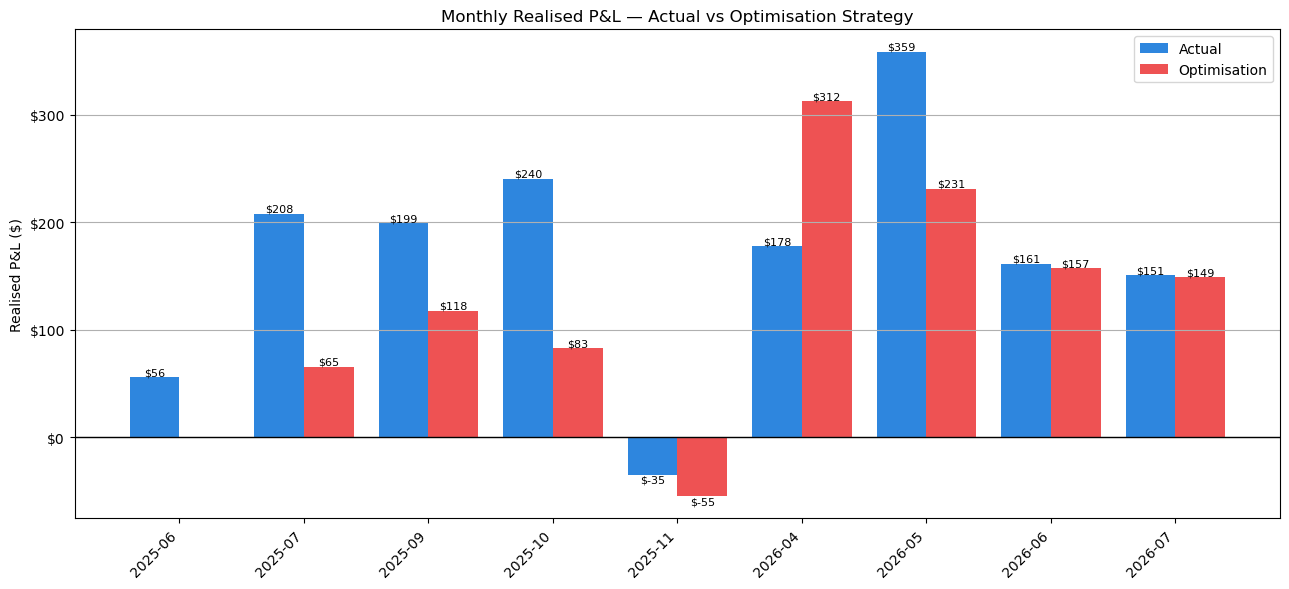

=== Monthly realized P&L ===
          Actual Optimisation Gap (Actual − Opt)
2025-06   $55.77        $0.00            $+55.77
2025-07  $207.83       $65.26           $+142.56
2025-09  $199.08      $117.66            $+81.42
2025-10  $240.24       $82.82           $+157.43
2025-11  $-35.25      $-54.85            $+19.60
2026-04  $177.83      $312.47           $-134.65
2026-05  $358.82      $231.33           $+127.49
2026-06  $161.47      $157.22             $+4.25
2026-07  $150.53      $148.82             $+1.71

Actual total:       $1,516.32
Optimisation total: $1,060.73
Gap:                $+455.59


In [81]:
# ---------------- monthly realized P&L: actual vs shadow ----------------
# Aggregate both to monthly totals
actual_monthly = (
    sell_pnl_df
    .assign(Month=lambda d: pd.to_datetime(d["Date"]).dt.to_period("M"))
    .groupby("Month")["Realised P&L ($)"]
    .sum()
)

shadow_monthly = (
    shadow_realised_df[shadow_realised_df["Ticker"] != "_shortfall_"]
    .assign(Month=lambda d: pd.to_datetime(d["Date"]).dt.to_period("M"))
    .groupby("Month")["Realised P&L"]
    .sum()
)

# Align both to the same monthly index
all_months = actual_monthly.index.union(shadow_monthly.index).sort_values()
actual_m   = actual_monthly.reindex(all_months, fill_value=0)
shadow_m   = shadow_monthly.reindex(all_months, fill_value=0)

# Plot
x     = np.arange(len(all_months))
width = 0.4

plt.figure(figsize=(13, 6))
plt.bar(x - width/2, actual_m.values, width, label="Actual",       color="#2e86de")
plt.bar(x + width/2, shadow_m.values, width, label="Optimisation", color="#ee5253")
plt.axhline(0, color="black", linewidth=1)

plt.xticks(x, [m.strftime("%Y-%m") for m in all_months], rotation=45, ha="right")
plt.title("Monthly Realised P&L — Actual vs Optimisation Strategy")
plt.ylabel("Realised P&L ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.legend()
plt.grid(True, axis="y")

# Value labels on top of each bar
for i, v in enumerate(actual_m.values):
    if v != 0:
        plt.text(i - width/2, v, f"${v:,.0f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
for i, v in enumerate(shadow_m.values):
    if v != 0:
        plt.text(i + width/2, v, f"${v:,.0f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.show()

# Compact summary table
summary = pd.DataFrame({
    "Actual":       actual_m.map("${:,.2f}".format),
    "Optimisation": shadow_m.map("${:,.2f}".format),
    "Gap (Actual − Opt)": (actual_m - shadow_m).map("${:+,.2f}".format),
})
summary.index = [m.strftime("%Y-%m") for m in all_months]
print("=== Monthly realized P&L ===")
print(summary.to_string())
print(f"\nActual total:       ${actual_m.sum():,.2f}")
print(f"Optimisation total: ${shadow_m.sum():,.2f}")
print(f"Gap:                ${actual_m.sum() - shadow_m.sum():+,.2f}")

# DASHBOARD

In [82]:
# ---------------- 1. Portfolio value over time ----------------
fig_value = go.Figure()
fig_value.add_trace(go.Scatter(x=portfolio_value.index, y=portfolio_value.values,
                               name="Portfolio Value", line=dict(width=2)))
fig_value.add_trace(go.Scatter(x=portfolio_cost_basis.index, y=portfolio_cost_basis.values,
                               name="Cost Basis", line=dict(width=2)))
fig_value.add_trace(go.Scatter(x=invested_capital.index, y=invested_capital.values,
                               name="Invested Capital", line=dict(width=2)))
fig_value.update_layout(title="Portfolio Value Over Time",
                        xaxis_title="Date", yaxis_title="USD",
                        yaxis_tickprefix="$", yaxis_tickformat=",",
                        height=450, template="plotly_white")

# ---------------- 2. Current allocation ----------------
latest_positions = position_values.iloc[-1]
latest_positions = latest_positions[latest_positions > 0]
asset_type_values = latest_positions.groupby(ticker_asset_type.loc[latest_positions.index]).sum()
latest_pct = (latest_positions / latest_positions.sum()).sort_values()

fig_alloc = make_subplots(rows=1, cols=2,
                          specs=[[{"type": "pie"}, {"type": "bar"}]],
                          subplot_titles=("By Asset Type", "By Ticker (%)"))
fig_alloc.add_trace(go.Pie(labels=asset_type_values.index,
                           values=asset_type_values.values,
                           hole=0.3), row=1, col=1)
fig_alloc.add_trace(go.Bar(y=latest_pct.index, x=latest_pct.values,
                           orientation="h",
                           text=[f"{v:.1%}" for v in latest_pct.values],
                           textposition="outside",
                           marker_color=["#ee5253" if ticker_asset_type[t] == "Equity"
                                         else "#2e86de" for t in latest_pct.index]),
                   row=1, col=2)
fig_alloc.update_xaxes(tickformat=".0%", row=1, col=2)
fig_alloc.update_layout(title="Current Allocation", height=500,
                        showlegend=False, template="plotly_white")

# ---------------- 3. P&L breakdown chart ----------------
fig_pnl = go.Figure()
fig_pnl.add_trace(go.Scatter(x=unrealised_pnl.index, y=unrealised_pnl.values,
                             name="Unrealised P&L", line=dict(width=2)))
fig_pnl.add_trace(go.Scatter(x=realised_pnl.index, y=realised_pnl.values,
                             name="Realised P&L", line=dict(width=2)))
fig_pnl.add_trace(go.Scatter(x=total_pnl.index, y=total_pnl.values,
                             name="Total P&L", line=dict(width=3)))
fig_pnl.add_hline(y=0, line_color="black", line_width=1)
fig_pnl.update_layout(title="Portfolio P&L Breakdown",
                      xaxis_title="Date", yaxis_title="USD",
                      yaxis_tickprefix="$", yaxis_tickformat=",",
                      height=450, template="plotly_white")

# ---------------- 4. P&L summary cards ----------------
current_unrealised = unrealised_pnl.iloc[-1]
current_realised   = realised_pnl.iloc[-1]
current_total      = total_pnl.iloc[-1]
current_value      = portfolio_value.iloc[-1]

def card(label, value, is_pnl=True):
    color = "#27ae60" if (is_pnl and value >= 0) else ("#c0392b" if is_pnl else "#2c3e50")
    return f"""
    <div class="card">
        <div class="card-label">{label}</div>
        <div class="card-value" style="color: {color}">${value:,.2f}</div>
    </div>"""

summary_cards = (
    card("Portfolio Value", current_value, is_pnl=False) +
    card("Total P&L", current_total) +
    card("Unrealised P&L", current_unrealised) +
    card("Realised P&L", current_realised)
)

# ---------------- 5. Per-asset holdings table ----------------
display_cols = ["Ticker", "Shares", "Last price", "AC/share",
                "Market value (US$)", "Tot gain UNRL (US$)", "Tot gain UNRL (%)",
                "Realised gain (US$)"]
table_df = summary_df[display_cols].copy()
for col in ["Last price", "AC/share", "Market value (US$)",
            "Tot gain UNRL (US$)", "Realised gain (US$)"]:
    table_df[col] = table_df[col].map(lambda x: f"${x:,.2f}")
table_df["Tot gain UNRL (%)"] = table_df["Tot gain UNRL (%)"].map(lambda x: f"{x:.2%}")
table_df["Shares"] = table_df["Shares"].map(lambda x: f"{x:,.4f}")

holdings_table = table_df.to_html(index=False, classes="holdings", border=0)

# ---------------- Assemble HTML ----------------
html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Portfolio Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
       background: #f5f6fa; margin: 0; padding: 20px; color: #2c3e50; }}
h1 {{ text-align: center; margin-bottom: 10px; }}
.timestamp {{ text-align: center; color: #7f8c8d; margin-bottom: 30px; }}
.cards {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
         gap: 15px; margin-bottom: 30px; }}
.card {{ background: white; padding: 20px; border-radius: 8px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.05); text-align: center; }}
.card-label {{ font-size: 0.85em; color: #7f8c8d; text-transform: uppercase; }}
.card-value {{ font-size: 1.6em; font-weight: 600; margin-top: 8px; }}
.chart {{ background: white; padding: 15px; border-radius: 8px;
         box-shadow: 0 2px 4px rgba(0,0,0,0.05); margin-bottom: 20px; }}
.holdings {{ width: 100%; border-collapse: collapse; background: white; }}
.holdings th, .holdings td {{ padding: 10px; text-align: right; border-bottom: 1px solid #ecf0f1; }}
.holdings th {{ background: #34495e; color: white; text-align: center; }}
.holdings td:first-child, .holdings th:first-child {{ text-align: left; font-weight: 600; }}
.section-title {{ font-size: 1.2em; margin: 25px 0 10px; color: #34495e; }}
</style>
</head>
<body>
<h1>Portfolio Dashboard</h1>
<div class="timestamp">Generated {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}</div>

<div class="cards">{summary_cards}</div>

<div class="chart" id="chart_value"></div>
<div class="chart" id="chart_alloc"></div>
<div class="chart" id="chart_pnl"></div>

<div class="section-title">Current Holdings</div>
<div class="chart">{holdings_table}</div>

<script>
Plotly.newPlot('chart_value', {fig_value.to_json()}.data, {fig_value.to_json()}.layout, {{responsive: true}});
Plotly.newPlot('chart_alloc', {fig_alloc.to_json()}.data, {fig_alloc.to_json()}.layout, {{responsive: true}});
Plotly.newPlot('chart_pnl', {fig_pnl.to_json()}.data, {fig_pnl.to_json()}.layout, {{responsive: true}});
</script>
</body>
</html>
"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Dashboard written to dashboard.html")

Dashboard written to dashboard.html


In [ ]:
I want to